# Dual-Stage Thermoelastic SEMM Pipeline

> ### FOR THE WRITING AGENT
>
> **This notebook is NOT one of the article's expansion methods.** It documents an
> attempted approach that was ultimately discarded in favour of the simpler expansion
> methods (transmissibility and direct PSD notebooks).
>
> **What this notebook does:**
> - **Stage 1** (Sections 1-2): 6 hammer-impact input cases &rarr; SEMM works well
>   (overdetermined system, standard thermoelastic SEMM)
> - **Stage 2** (Sections 3-5): 1 base-excitation input case &rarr; SEMM fails
>   (severely underdetermined)
>
> **Why it fails:**
> SEMM requires multiple independent input cases to resolve the spatial stress field.
> With 6 hammer impacts in Stage 1, the system is overdetermined and SEMM produces
> reliable results. In Stage 2, there is only **1 base-excitation input case**
> (single shaker, single broadband profile). This makes the equivalent-input
> inversion ill-posed &mdash; SEMM cannot distinguish between spatial patterns with
> a single input.
>
> **Evidence of failure:**
> - The relative SEMM update ratio is **3.82&times;** (382% change from parent model),
>   far exceeding the expected ~1.0 for a well-conditioned update
> - Workarounds attempted (virtual base point, DoF decimation every 3rd node) are
>   regularisation hacks that do not solve the fundamental data insufficiency
>
> **For the article:**
> - Mention that the full dual-stage SEMM approach was attempted
> - State it requires multiple independent input cases, which base excitation
>   does not provide (single shaker = single input case, regardless of frequency content)
> - Cite this as motivation for developing the simpler expansion methods
>   (transmissibility and direct PSD), which bypass SEMM in Stage 2 entirely
> - The Stage 1 SEMM result (hammer impacts) is still used by both expansion methods
>   for mode shape extraction
>
> **Data paths:** Left pointing to `best_one` measurement (historical record).
> No need to re-run &mdash; the method itself is being discarded, not the data.

This notebook runs:
1. Stage 1 hammer-based SEMM (force reference)
2. Stage 2 base-excitation SEMM using acceleration reference and equivalent-input parent conversion

In [1]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# Make imports/path robust regardless of current working directory.
cwd = Path.cwd().resolve()
if cwd.name == 'dual_stage_base_pipeline':
    PROJECT_ROOT = cwd.parent
else:
    PROJECT_ROOT = cwd

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

try:
    from dual_stage_base_pipeline.semm_thermoelastic_pipeline import (
        SEMMThermoelasticPipeline,
        PathsConfig,
        Stage1Config,
        Stage2Config,
        SEMMConfig,
    )
except ModuleNotFoundError:
    # Fallback when running with dual_stage_base_pipeline as cwd.
    from semm_thermoelastic_pipeline import (
        SEMMThermoelasticPipeline,
        PathsConfig,
        Stage1Config,
        Stage2Config,
        SEMMConfig,
    )

print('PROJECT_ROOT =', PROJECT_ROOT)


PROJECT_ROOT = C:\Users\jasas\Work\Clanki\Clanek_2\Trigger_and_acquisition


In [ ]:
# ---------------- CONFIG ----------------
paths_cfg = PathsConfig(
    project_root=str(PROJECT_ROOT),
    solver_script='stage1_solver/plate_stress_modal_superposition_force_pointmass_v2_camfreq_20260206_1239.py',
    stage2_camera_hcc=r'C:\Users\jasas\Work\Clanki\Clanek_2\data\experiment_20260305\stage2_camera\DefaultName_20260305T073259507\_20260305T073259507_20260305T073259947.hcc',
    stage2_camera_npy=r'C:\Users\jasas\Work\Clanki\Clanek_2\data\experiment_20260305\stage2_camera\DefaultName_20260305T073259507\_20260305T073259507_20260305T073259947.npy',
    stage2_accel_pkl=r'C:\Users\jasas\Work\Clanki\Clanek_2\data\experiment_20260305\stage2_shaker\20260305_073124_base_excitation.pkl',
    stage2_crop_json='dual_stage_base_pipeline/configs/stage2_crop.json',
    output_root='dual_stage_base_pipeline/outputs',
    stage1_run_root='dual_stage_base_pipeline/outputs/_stage1_numerical_runs',
)

stage1_cfg = Stage1Config(
    f_min=50.0,
    f_max=300.0,
    n_segments=1,             # single FFT for impact data (no Welch averaging)
    fs_ir_fallback=2000.0,
    crop={'row_start': 18, 'row_end': 121, 'col_start': 13, 'col_end': 119},
    reduce_factor=3,
    enable_impact_sync_crop=True,
)

stage2_cfg = Stage2Config(
    crop_mode='inherit_stage1',  # 'inherit_stage1' or 'manual'
    stage2_crop=None,
    n_segments=5,
    reduce_factor=None,
    acc_task_name='AccelerationTask',
    acc_channel_name='Acceleration',
    acc_in_g=True,
    cache_stage2_camera_npy=True,
    overlay_component=3,
    parent_basis='Y_SEMM',
    parent_q_mode='virtual_base',
    virtual_base_mass_kg=1.4e-4,
    virtual_base_sigma_m=None,
    equiv_regularization=1e-12,
    # Important: use every Nth interface DoF for q-identification.
    # 1 = use all DoFs (can make stage-2 parent almost identical to SEMM).
    equiv_fit_every_n_dof=3,
)

semm_cfg = SEMMConfig(
    f_semm_min=40.0,
    f_semm_max=300.0,
    semm_lines_per_chunk=1,
    log_every_n_chunks=5,
    semm_type='fully-extend-svd',
)

pipe = SEMMThermoelasticPipeline(paths=paths_cfg, stage1=stage1_cfg, stage2=stage2_cfg, semm=semm_cfg)

# quick path sanity check
print('Pipeline initialized.')
print('stage2_camera_hcc ->', (PROJECT_ROOT / Path(paths_cfg.stage2_camera_hcc)).exists())
print('stage2_accel_pkl  ->', (PROJECT_ROOT / Path(paths_cfg.stage2_accel_pkl)).exists())

In [3]:
# ---------------- STAGE 1 ----------------
stage1_cam = pipe.build_hammer_stage1()
stage1 = pipe.run_stage1_numerical_and_semm()

print('Stage 1 complete')
print('Y_SEMM shape:', stage1['Y_SEMM'].shape)
print('freq range:', float(stage1['freqs'][0]), '->', float(stage1['freqs'][-1]), 'Hz')


Stage-1 SEMM
Start             : 2026-02-23 08:32:26
Band              : 45.596 .. 299.827 Hz
Selected lines    : 369
Chunk size        : 1
Total chunks      : 369
SEMM type         : fully-extend-svd


Stage-1 SEMM:   0%|          | 0/369 [00:00<?, ?line/s]

[   1/369] lines    1-   1/369 | f=  45.596..  45.596 Hz | chunk=  0.12s | elapsed=    0.1s | eta=   42.4s
[   5/369] lines    5-   5/369 | f=  48.359..  48.359 Hz | chunk=  0.11s | elapsed=    0.5s | eta=   40.0s
[  10/369] lines   10-  10/369 | f=  51.813..  51.813 Hz | chunk=  0.11s | elapsed=    1.1s | eta=   39.3s
[  15/369] lines   15-  15/369 | f=  55.268..  55.268 Hz | chunk=  0.10s | elapsed=    1.6s | eta=   38.0s
[  20/369] lines   20-  20/369 | f=  58.722..  58.722 Hz | chunk=  0.10s | elapsed=    2.1s | eta=   37.0s
[  25/369] lines   25-  25/369 | f=  62.176..  62.176 Hz | chunk=  0.10s | elapsed=    2.7s | eta=   36.5s
[  30/369] lines   30-  30/369 | f=  65.630..  65.630 Hz | chunk=  0.11s | elapsed=    3.2s | eta=   36.1s
[  35/369] lines   35-  35/369 | f=  69.085..  69.085 Hz | chunk=  0.10s | elapsed=    3.7s | eta=   35.7s
[  40/369] lines   40-  40/369 | f=  72.539..  72.539 Hz | chunk=  0.10s | elapsed=    4.3s | eta=   35.1s
[  45/369] lines   45-  45/369 | f=  

In [4]:
# import os
# os.environ["MPLBACKEND"] = "QtAgg"   # or "Qt5Agg" for older Matplotlib

# import matplotlib
# print("backend before pyplot:", matplotlib.get_backend())

# import matplotlib.pyplot as plt
# plt.figure()
# plt.plot([0, 1, 2], [0, 1, 0])
# plt.title("Qt window test")
# plt.show()

# %matplotlib qt

In [1]:
# ---------------- STAGE 2 LOAD + CROP POLICY ----------------
cache_path = pipe.cache_stage2_camera_to_npy(overwrite=False)
print('Stage-2 camera cache path:', cache_path)

stage2_raw = pipe.load_base_measurement()

# Default path: inherit stage-1 crop
#if pipe.stage2_cfg.crop_mode == 'inherit_stage1':
#    print('Stage-2 crop mode: inherit_stage1')

# Optional manual path:
pipe.stage2_cfg.crop_mode = 'manual'
# 2) pick crop interactively
#picked = pipe.pick_crop_two_clicks(stage2_raw['images'], frame_index=0)
#pipe.set_stage2_crop(picked)
#pipe.save_stage2_crop(pipe.paths.stage2_crop_json)
#future runs can reuse saved crop with manual mode
pipe.load_stage2_crop(pipe.paths.stage2_crop_json)

print('Base camera source:', stage2_raw['camera_source'])
print('Camera cache used:', stage2_raw['camera_cache_path'])
print('Camera cache saved this run:', stage2_raw['camera_cache_saved'])
print('Acceleration units after conversion:', stage2_raw['acc_units'])
print('Acceleration scale applied:', stage2_raw['acc_scale_applied'])


NameError: name 'pipe' is not defined

In [6]:
# ---------------- STAGE 2 BUILD + SEMM ----------------
stage2_overlay = pipe.build_base_overlay_stress_acc()
Y_parent_acc = pipe.build_stage2_parent_acc(stage2_overlay=stage2_overlay)
stage2 = pipe.run_stage2_semm(parent_acc=Y_parent_acc)

print('Stage 2 complete')
print('Y_overlay_base shape:', stage2_overlay['Y_overlay_base'].shape)
print('Y_parent_acc shape:', Y_parent_acc.shape)
print('Y_SEMM_stage2 shape:', stage2['Y_SEMM_stage2'].shape)
print('q source:', pipe.state['stage2'].get('q_equiv_source'))

# check how much SEMM changed the parent in stage 2
Y2_parent = np.asarray(pipe.state['stage2']['Y_parent_acc'])
Y2_semm = np.asarray(pipe.state['stage2']['Y_SEMM_stage2'])
rel_update = np.linalg.norm(Y2_semm - Y2_parent) / (np.linalg.norm(Y2_parent) + 1e-30)
print(f'Relative stage-2 SEMM update ||Y_semm - Y_parent|| / ||Y_parent|| = {rel_update:.6e}')

if pipe.state['stage2'].get('q_equiv_source') == 'overlay_fit':
    print('Equivalent-input fit DoFs used:', pipe.state['stage2'].get('fit_dof_count_used'),
          '/', pipe.state['stage2'].get('fit_dof_count_total'),
          f"(step={pipe.state['stage2'].get('fit_dof_step')})")
else:
    vb = pipe.state['stage2'].get('virtual_base_reference', {})
    print('Virtual-base q settings:', vb)


Stage-2 SEMM
Start             : 2026-02-23 08:33:16
Band              : 45.596 .. 299.827 Hz
Selected lines    : 369
Chunk size        : 1
Total chunks      : 369
SEMM type         : fully-extend-svd


Stage-2 SEMM:   0%|          | 0/369 [00:00<?, ?line/s]

[   1/369] lines    1-   1/369 | f=  45.596..  45.596 Hz | chunk=  0.08s | elapsed=    0.1s | eta=   31.0s
[   5/369] lines    5-   5/369 | f=  48.359..  48.359 Hz | chunk=  0.08s | elapsed=    0.4s | eta=   28.5s
[  10/369] lines   10-  10/369 | f=  51.813..  51.813 Hz | chunk=  0.07s | elapsed=    0.8s | eta=   27.8s
[  15/369] lines   15-  15/369 | f=  55.268..  55.268 Hz | chunk=  0.08s | elapsed=    1.2s | eta=   27.4s
[  20/369] lines   20-  20/369 | f=  58.722..  58.722 Hz | chunk=  0.08s | elapsed=    1.6s | eta=   27.1s
[  25/369] lines   25-  25/369 | f=  62.176..  62.176 Hz | chunk=  0.08s | elapsed=    1.9s | eta=   26.8s
[  30/369] lines   30-  30/369 | f=  65.630..  65.630 Hz | chunk=  0.08s | elapsed=    2.3s | eta=   26.4s
[  35/369] lines   35-  35/369 | f=  69.085..  69.085 Hz | chunk=  0.08s | elapsed=    2.7s | eta=   26.0s
[  40/369] lines   40-  40/369 | f=  72.539..  72.539 Hz | chunk=  0.08s | elapsed=    3.1s | eta=   25.6s
[  45/369] lines   45-  45/369 | f=  

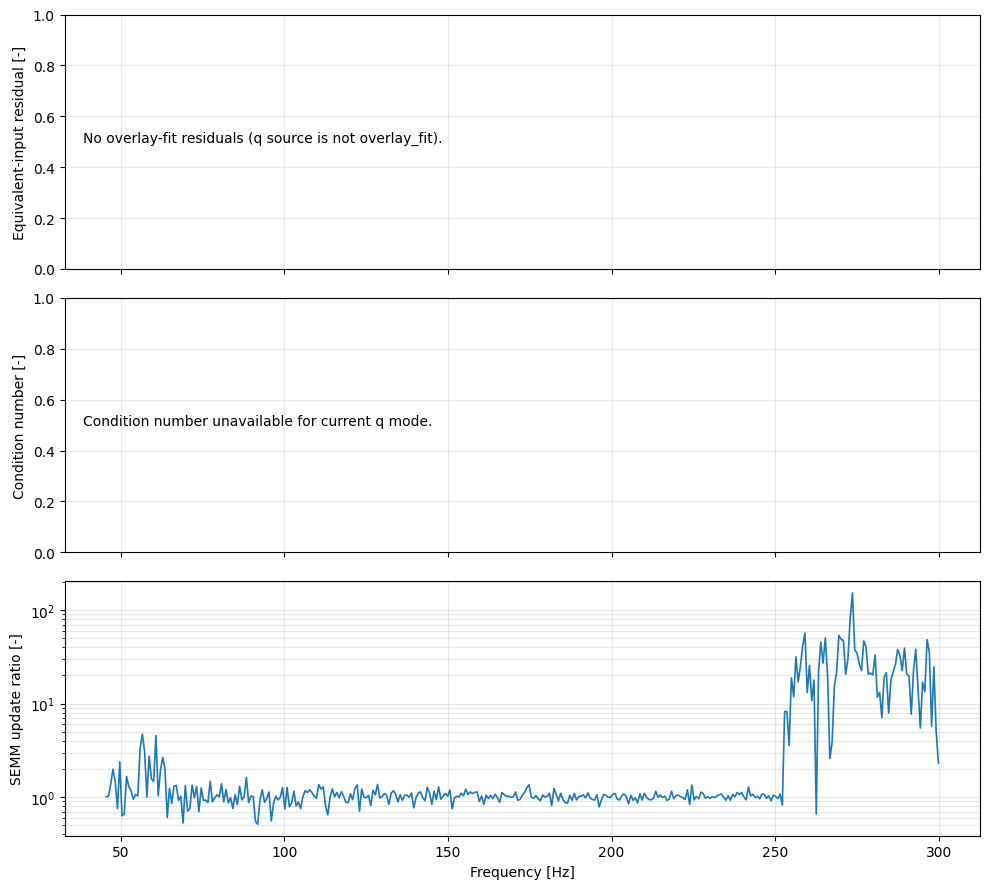

Stage-2 crop used: {'row_start': 3, 'row_end': 93, 'col_start': 10, 'col_end': 103}
q source: virtual_base_stage1_only


In [7]:
# ---------------- DIAGNOSTICS ----------------
freq = np.asarray(pipe.state['stage1']['freqs'], dtype=float)
res_fit = np.asarray(pipe.state['stage2'].get('fit_residual', np.full_like(freq, np.nan)), dtype=float)
res_all = np.asarray(pipe.state['stage2'].get('fit_residual_all_dofs', np.full_like(freq, np.nan)), dtype=float)
cond = np.asarray(pipe.state['stage2'].get('fit_condition', np.full_like(freq, np.nan)), dtype=float)

fig, axs = plt.subplots(3, 1, figsize=(10, 9), sharex=True)

if np.all(np.isnan(res_fit)) and np.all(np.isnan(res_all)):
    axs[0].text(0.02, 0.5, 'No overlay-fit residuals (q source is not overlay_fit).', transform=axs[0].transAxes)
else:
    axs[0].plot(freq, res_fit, lw=1.2, label='fit residual (used DoFs)')
    axs[0].plot(freq, res_all, lw=1.0, label='fit residual (all interface DoFs)', alpha=0.85)
    axs[0].legend(fontsize=8)
axs[0].set_ylabel('Equivalent-input residual [-]')
axs[0].grid(True, alpha=0.3)

cond_plot = np.where(np.isfinite(cond) & (cond > 0), cond, np.nan)
if np.any(np.isfinite(cond_plot)):
    axs[1].semilogy(freq, cond_plot, lw=1.2)
else:
    axs[1].text(0.02, 0.5, 'Condition number unavailable for current q mode.', transform=axs[1].transAxes)
axs[1].set_ylabel('Condition number [-]')
axs[1].grid(True, which='both', alpha=0.3)

Y2_parent = np.asarray(pipe.state['stage2']['Y_parent_acc'])
Y2_semm = np.asarray(pipe.state['stage2']['Y_SEMM_stage2'])
rel_per_f = np.linalg.norm(Y2_semm - Y2_parent, axis=(1, 2)) / (np.linalg.norm(Y2_parent, axis=(1, 2)) + 1e-30)
axs[2].semilogy(freq, rel_per_f, lw=1.2)
axs[2].set_ylabel('SEMM update ratio [-]')
axs[2].set_xlabel('Frequency [Hz]')
axs[2].grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.show()

print('Stage-2 crop used:', pipe.state['stage2'].get('stage2_crop_used'))
print('q source:', pipe.state['stage2'].get('q_equiv_source'))


## Extended plots (Stage 1 + Stage 2)
This section adds FRF plots and peak-based spatial maps for two resonances (~50 Hz and ~150-200 Hz), similar to the original notebook.


In [8]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

stage1_data = pipe.state.get('stage1', {})
stage2_data = pipe.state.get('stage2', {})

required_stage1 = [
    'freqs', 'Y_final2', 'Y_SEMM', 'Y_camera', 'node_coords', 'camera_positions',
    'rows', 'cols', 'df_imp_use', 'component_overlay', 'b_nodes', 'cam_to_num_idx', 'Y_overlay_num'
]
missing_stage1 = [k for k in required_stage1 if k not in stage1_data]
if missing_stage1:
    raise RuntimeError(f"Missing stage-1 keys for plotting: {missing_stage1}. Run Stage 1 cells first.")

freq_axis = np.asarray(stage1_data['freqs'], dtype=float)
Y_final2 = np.asarray(stage1_data['Y_final2'])
Y_SEMM = np.asarray(stage1_data['Y_SEMM'])
Y_camera = np.asarray(stage1_data['Y_camera'])
Y_overlay_num = np.asarray(stage1_data['Y_overlay_num'])

node_coords = np.asarray(stage1_data['node_coords'], dtype=float)
camera_positions = np.asarray(stage1_data['camera_positions'], dtype=float)
rows = int(stage1_data['rows'])
cols = int(stage1_data['cols'])

case_labels = stage1_data['df_imp_use']['Case'].astype(str).tolist()
COMPONENT_OVERLAY = int(stage1_data['component_overlay'])
b_nodes = np.asarray(stage1_data['b_nodes'], dtype=int)
cam_to_num_idx = np.asarray(stage1_data['cam_to_num_idx'], dtype=int)

# Two target resonance bands (adjust if needed)
PEAK_BANDS = [
    {"name": "Peak 1 (~50 Hz)", "fmin": 40.0, "fmax": 80.0},
    {"name": "Peak 2 (~150-200 Hz)", "fmin": 130.0, "fmax": 220.0},
]


def rc_to_pix(r, c, cols_local):
    return int(r) * int(cols_local) + int(c)


def pix_to_rc(pix, cols_local):
    pix = int(pix)
    return pix // int(cols_local), pix % int(cols_local)


def nearest_freq_idx(freq_vec, f_hz):
    freq_vec = np.asarray(freq_vec, dtype=float)
    return int(np.argmin(np.abs(freq_vec - float(f_hz))))


def pick_peak_idx(metric, mask):
    y = np.asarray(metric, dtype=float)
    y_band = np.nan_to_num(y[mask], nan=-np.inf, posinf=-np.inf, neginf=-np.inf)
    idx_band = np.where(mask)[0]
    peaks, _ = find_peaks(y_band)
    if peaks.size == 0:
        i_rel = int(np.argmax(y_band))
    else:
        i_rel = int(peaks[np.argmax(y_band[peaks])])
    return int(idx_band[i_rel])


def pick_peak_idx_in_range(metric, freq_vec, fmin, fmax):
    freq_vec = np.asarray(freq_vec, dtype=float)
    mask = (freq_vec >= float(fmin)) & (freq_vec <= float(fmax))
    if not np.any(mask):
        raise ValueError(f"No frequencies in band [{fmin}, {fmax}] Hz")
    return pick_peak_idx(metric, mask)


def pick_peaks_for_bands(metric, freq_vec, bands):
    out = []
    for b in bands:
        k = pick_peak_idx_in_range(metric, freq_vec, b['fmin'], b['fmax'])
        out.append((b['name'], b['fmin'], b['fmax'], int(k), float(freq_vec[k])))
    return out


def plot_frf_pixel_cases(freq, Y_cam, rows_local, cols_local, labels, cases,
                         r=None, c=None, pix=None, db=True, show_phase=True, unwrap_phase=True):
    if pix is None:
        if r is None or c is None:
            raise ValueError('Provide either pix=... or (r=..., c=...)')
        pix = rc_to_pix(r, c, cols_local)

    if isinstance(cases, (str, int)):
        cases = [cases]

    k_cases = []
    for cs in cases:
        if isinstance(cs, str):
            k_cases.append(labels.index(cs))
        else:
            k_cases.append(int(cs))

    title = f"FRF | pix={pix} (r,c={pix_to_rc(pix, cols_local)})"

    if show_phase:
        fig, ax = plt.subplots(2, 1, figsize=(9, 6), sharex=True)
        for k in k_cases:
            H = Y_cam[:, pix, k]
            mag = np.abs(H)
            if db:
                mag_plot = 20 * np.log10(np.maximum(mag, 1e-30))
                ylab = 'Magnitude [dB]'
            else:
                mag_plot = mag
                ylab = 'Magnitude [abs]'
            ax[0].plot(freq, mag_plot, label=labels[k])
        ax[0].set_ylabel(ylab)
        ax[0].set_title(title)
        ax[0].grid(True)
        ax[0].legend(ncol=2, fontsize=8)

        for k in k_cases:
            H = Y_cam[:, pix, k]
            ph = np.angle(H)
            if unwrap_phase:
                ph = np.unwrap(ph)
            ax[1].plot(freq, ph, label=labels[k])
        ax[1].set_ylabel('Phase [rad]')
        ax[1].set_xlabel('Frequency [Hz]')
        ax[1].grid(True)
        plt.tight_layout()
    else:
        plt.figure(figsize=(9, 4))
        for k in k_cases:
            H = Y_cam[:, pix, k]
            mag = np.abs(H)
            if db:
                mag_plot = 20 * np.log10(np.maximum(mag, 1e-30))
                ylab = 'Magnitude [dB]'
            else:
                mag_plot = mag
                ylab = 'Magnitude [abs]'
            plt.plot(freq, mag_plot, label=labels[k])
        plt.ylabel(ylab)
        plt.xlabel('Frequency [Hz]')
        plt.title(title)
        plt.grid(True)
        plt.legend(ncol=2, fontsize=8)
        plt.tight_layout()


def plot_map_freq_case(freq, Y_cam, rows_local, cols_local, labels, case, f_hz=None, f_idx=None,
                       quantity='mag', db=False, percentile_clip=(1, 99)):
    if f_idx is None:
        if f_hz is None:
            raise ValueError('Provide f_idx or f_hz')
        f_idx = nearest_freq_idx(freq, f_hz)
    else:
        f_idx = int(f_idx)

    if isinstance(case, str):
        k_case = labels.index(case)
    else:
        k_case = int(case)

    H = Y_cam[f_idx, :, k_case].reshape(rows_local, cols_local)
    if quantity == 'mag':
        Z = np.abs(H)
        if db:
            Z = 20 * np.log10(np.maximum(Z, 1e-30))
            title_q = 'Magnitude [dB]'
        else:
            title_q = 'Magnitude [abs]'
    elif quantity == 'real':
        Z = np.real(H); title_q = 'Real'
    elif quantity == 'imag':
        Z = np.imag(H); title_q = 'Imag'
    elif quantity == 'phase':
        Z = np.angle(H); title_q = 'Phase [rad]'
    else:
        raise ValueError('quantity must be one of: mag, real, imag, phase')

    if percentile_clip is not None:
        lo, hi = np.percentile(Z[np.isfinite(Z)], list(percentile_clip))
        vmin, vmax = lo, hi
    else:
        vmin = vmax = None

    plt.figure(figsize=(7, 5))
    plt.imshow(Z, origin='upper', vmin=vmin, vmax=vmax)
    plt.colorbar()
    plt.title(f"{title_q} | case={labels[k_case]} | f={float(freq[f_idx]):.3f} Hz")
    plt.xlabel('col')
    plt.ylabel('row')
    plt.tight_layout()
    plt.show()


print('Stage-1 plotting context loaded.')
print('freq range:', float(freq_axis[0]), '->', float(freq_axis[-1]), 'Hz | n=', len(freq_axis))
print('cases:', case_labels)
print('grid:', rows, 'x', cols)
print('peak bands:', PEAK_BANDS)



Stage-1 plotting context loaded.
freq range: 45.59585492227979 -> 299.82728842832466 Hz | n= 369
cases: ['center_middle', 'center_top', 'left_top', 'left_middle', 'right_middle', 'right_top']
grid: 29 x 29
peak bands: [{'name': 'Peak 1 (~50 Hz)', 'fmin': 40.0, 'fmax': 80.0}, {'name': 'Peak 2 (~150-200 Hz)', 'fmin': 130.0, 'fmax': 220.0}]


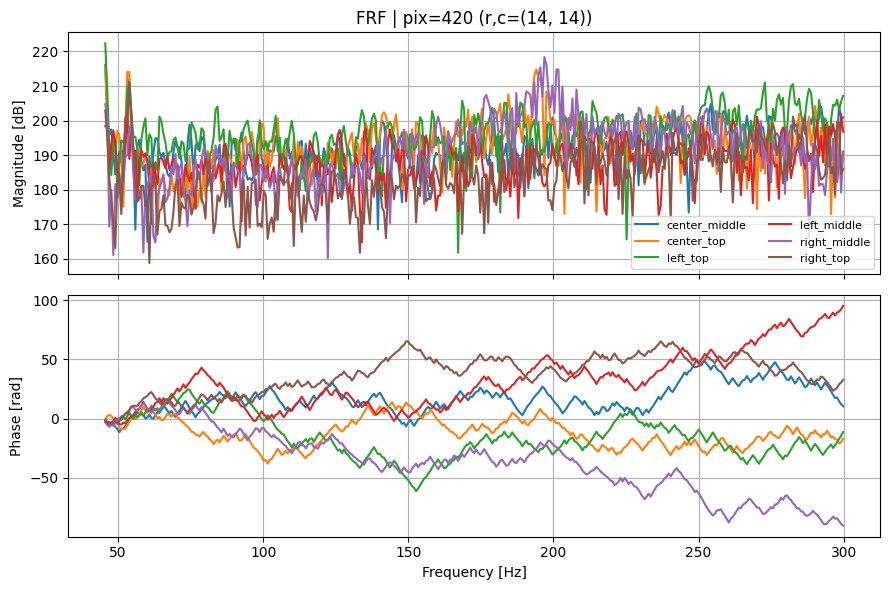

In [9]:
# Stage-1 camera FRFs at one selected pixel across all hammer cases
PLOT_R = rows // 2
PLOT_C = cols // 2

plot_frf_pixel_cases(
    freq_axis,
    Y_camera,
    rows,
    cols,
    case_labels,
    cases=case_labels,
    r=PLOT_R,
    c=PLOT_C,
    db=True,
    show_phase=True,
)


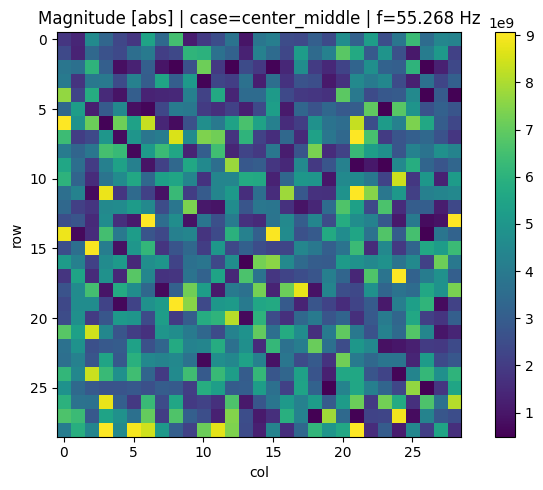

In [10]:
# Stage-1 camera map at chosen frequency/case
MAP_CASE = case_labels[0]
MAP_FREQ_HZ = 55.0

plot_map_freq_case(
    freq_axis,
    Y_camera,
    rows,
    cols,
    case_labels,
    case=MAP_CASE,
    f_hz=MAP_FREQ_HZ,
    quantity='mag',
    db=False,
)


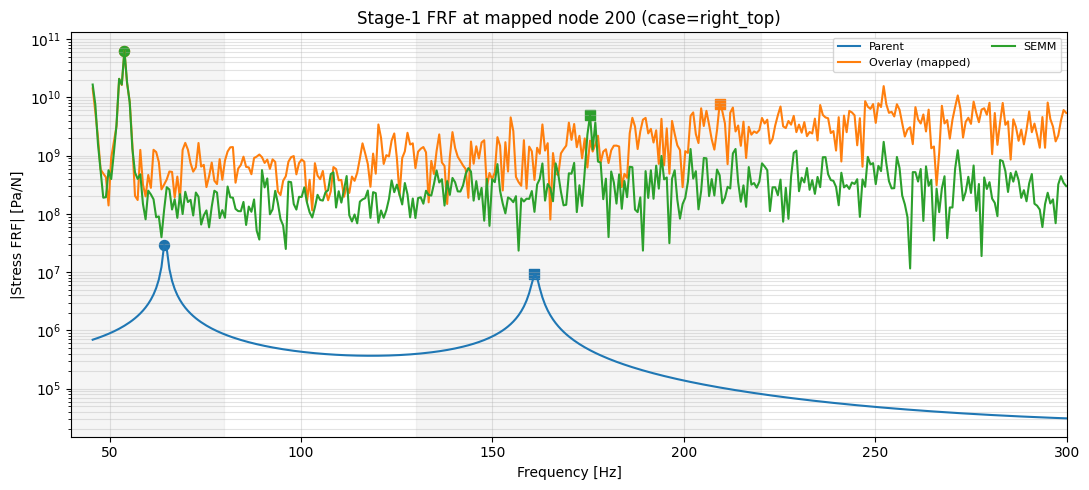

Peak 1 (~50 Hz): Parent=64.249 Hz | Overlay=53.886 Hz | SEMM=53.886 Hz
Peak 2 (~150-200 Hz): Parent=160.967 Hz | Overlay=209.326 Hz | SEMM=175.475 Hz


In [11]:

# Stage-1 mapped point FRF: Parent vs Overlay vs SEMM with two target peaks
CASE_IDX = min(5, Y_final2.shape[2] - 1)
J_B = min(200, len(b_nodes) - 1)
COMP = COMPONENT_OVERLAY
F_MIN_PLOT = 40.0
F_MAX_PLOT = 300.0

i_num = int(b_nodes[J_B])
parent_curve = np.abs(Y_final2[:, 4 * i_num + COMP, CASE_IDX])
overlay_curve = np.abs(Y_overlay_num[:, J_B, CASE_IDX])
semm_curve = np.abs(Y_SEMM[:, 4 * i_num + COMP, CASE_IDX])

metric_parent = np.asarray(parent_curve, dtype=float)
metric_overlay = np.asarray(overlay_curve, dtype=float)
metric_semm = np.asarray(semm_curve, dtype=float)

peaks_parent = pick_peaks_for_bands(metric_parent, freq_axis, PEAK_BANDS)
peaks_overlay = pick_peaks_for_bands(metric_overlay, freq_axis, PEAK_BANDS)
peaks_semm = pick_peaks_for_bands(metric_semm, freq_axis, PEAK_BANDS)

plt.figure(figsize=(11, 5))
plt.semilogy(freq_axis, np.maximum(parent_curve, 1e-30), label='Parent')
plt.semilogy(freq_axis, np.maximum(overlay_curve, 1e-30), label='Overlay (mapped)')
plt.semilogy(freq_axis, np.maximum(semm_curve, 1e-30), label='SEMM')

markers = ['o', 's']
for j, (_, fmin, fmax, kp, fp) in enumerate(peaks_parent):
    plt.scatter([fp], [parent_curve[kp]], marker=markers[j % len(markers)], s=52, color='C0')
    plt.axvspan(fmin, fmax, color='k', alpha=0.04)
for j, (_, _, _, ko, fo) in enumerate(peaks_overlay):
    plt.scatter([fo], [overlay_curve[ko]], marker=markers[j % len(markers)], s=52, color='C1')
for j, (_, _, _, ks, fs) in enumerate(peaks_semm):
    plt.scatter([fs], [semm_curve[ks]], marker=markers[j % len(markers)], s=52, color='C2')

plt.xlim(F_MIN_PLOT, F_MAX_PLOT)
plt.xlabel('Frequency [Hz]')
plt.ylabel('|Stress FRF| [Pa/N]')
plt.title(f'Stage-1 FRF at mapped node {i_num} (case={case_labels[CASE_IDX]})')
plt.grid(True, which='both', alpha=0.35)
plt.legend(ncol=2, fontsize=8)
plt.tight_layout()
plt.show()

for j, band in enumerate(PEAK_BANDS):
    print(
        f"{band['name']}: Parent={peaks_parent[j][4]:.3f} Hz | "
        f"Overlay={peaks_overlay[j][4]:.3f} Hz | SEMM={peaks_semm[j][4]:.3f} Hz"
    )



c:\Users\jasas\Work\Clanki\Clanek_2\Trigger_and_acquisition\venv\Lib\site-packages\matplotlib\tri\_triangulation.py:181: RuntimeWarning: invalid value encountered in cast
  triangles = np.asarray(triangles, dtype=np.int32)


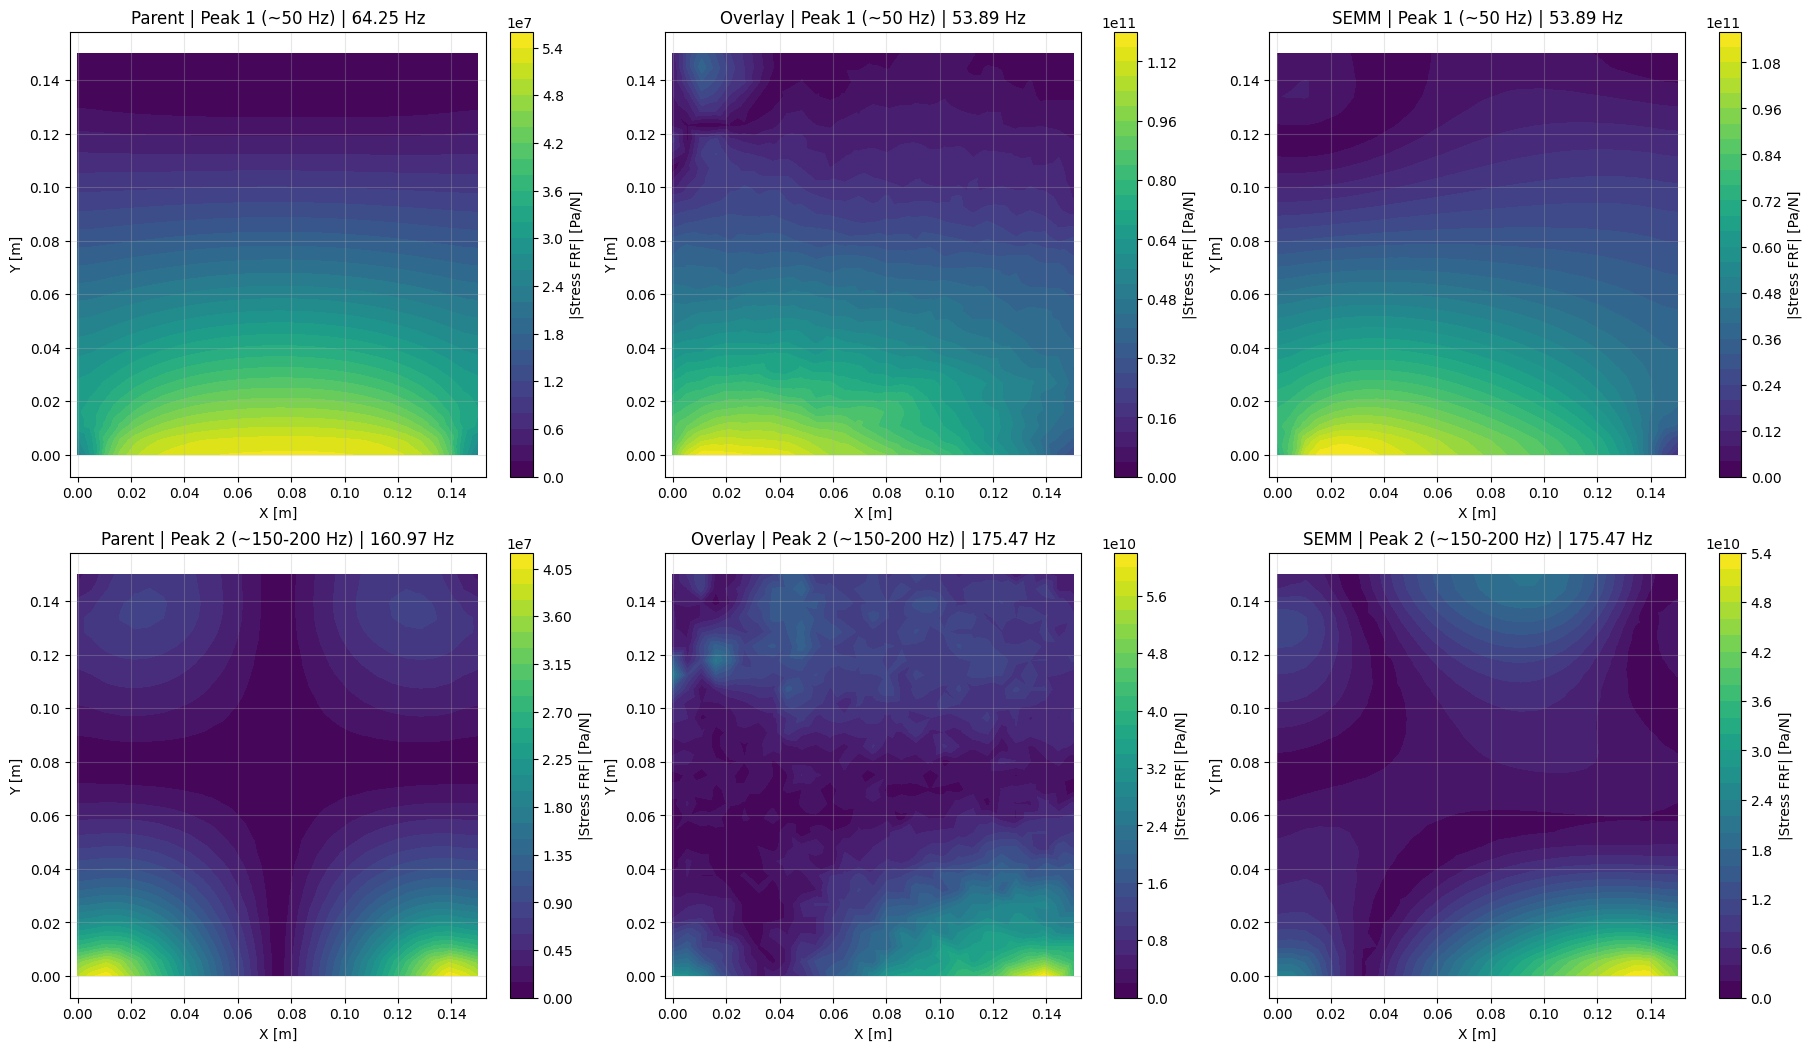

Peak 1 (~50 Hz): Parent=64.249 Hz | Overlay=53.886 Hz | SEMM=53.886 Hz
Peak 2 (~150-200 Hz): Parent=160.967 Hz | Overlay=175.475 Hz | SEMM=175.475 Hz


In [12]:

# Stage-1 peak maps for both target resonances (Parent / Overlay / SEMM)
CASE_PLOT_IDX = min(5, Y_final2.shape[2] - 1)
COMP = COMPONENT_OVERLAY

parent_all = np.asarray(Y_final2[:, COMP::4, CASE_PLOT_IDX])
overlay_all = np.asarray(Y_camera[:, :, CASE_PLOT_IDX])
semm_all = np.asarray(Y_SEMM[:, COMP::4, CASE_PLOT_IDX])

parent_metric = np.sqrt(np.mean(np.abs(parent_all) ** 2, axis=1))
overlay_metric = np.sqrt(np.mean(np.abs(overlay_all) ** 2, axis=1))
semm_metric = np.sqrt(np.mean(np.abs(semm_all) ** 2, axis=1))

peak_parent = pick_peaks_for_bands(parent_metric, freq_axis, PEAK_BANDS)
peak_overlay = pick_peaks_for_bands(overlay_metric, freq_axis, PEAK_BANDS)
peak_semm = pick_peaks_for_bands(semm_metric, freq_axis, PEAK_BANDS)

fig, axes = plt.subplots(len(PEAK_BANDS), 3, figsize=(18, 5.2 * len(PEAK_BANDS)), constrained_layout=True)
if len(PEAK_BANDS) == 1:
    axes = np.asarray([axes])

for r, band in enumerate(PEAK_BANDS):
    band_name = band['name']
    kp = peak_parent[r][3]
    ko = peak_overlay[r][3]
    ks = peak_semm[r][3]

    field_parent = np.abs(parent_all[kp])
    field_overlay = np.abs(overlay_all[ko])
    field_semm = np.abs(semm_all[ks])

    c0 = axes[r, 0].tricontourf(node_coords[:, 0], node_coords[:, 1], field_parent, levels=30)
    fig.colorbar(c0, ax=axes[r, 0], label='|Stress FRF| [Pa/N]')
    axes[r, 0].set_title(f"Parent | {band_name} | {freq_axis[kp]:.2f} Hz")
    axes[r, 0].set_xlabel('X [m]'); axes[r, 0].set_ylabel('Y [m]'); axes[r, 0].axis('equal'); axes[r, 0].grid(True, alpha=0.3)

    c1 = axes[r, 1].tricontourf(camera_positions[:, 0], camera_positions[:, 1], field_overlay, levels=30)
    fig.colorbar(c1, ax=axes[r, 1], label='|Stress FRF| [Pa/N]')
    axes[r, 1].set_title(f"Overlay | {band_name} | {freq_axis[ko]:.2f} Hz")
    axes[r, 1].set_xlabel('X [m]'); axes[r, 1].set_ylabel('Y [m]'); axes[r, 1].axis('equal'); axes[r, 1].grid(True, alpha=0.3)

    c2 = axes[r, 2].tricontourf(node_coords[:, 0], node_coords[:, 1], field_semm, levels=30)
    fig.colorbar(c2, ax=axes[r, 2], label='|Stress FRF| [Pa/N]')
    axes[r, 2].set_title(f"SEMM | {band_name} | {freq_axis[ks]:.2f} Hz")
    axes[r, 2].set_xlabel('X [m]'); axes[r, 2].set_ylabel('Y [m]'); axes[r, 2].axis('equal'); axes[r, 2].grid(True, alpha=0.3)

plt.show()

for r, band in enumerate(PEAK_BANDS):
    print(
        f"{band['name']}: Parent={peak_parent[r][4]:.3f} Hz | "
        f"Overlay={peak_overlay[r][4]:.3f} Hz | SEMM={peak_semm[r][4]:.3f} Hz"
    )



Band: Peak 1 (~50 Hz) [40.0, 80.0] Hz


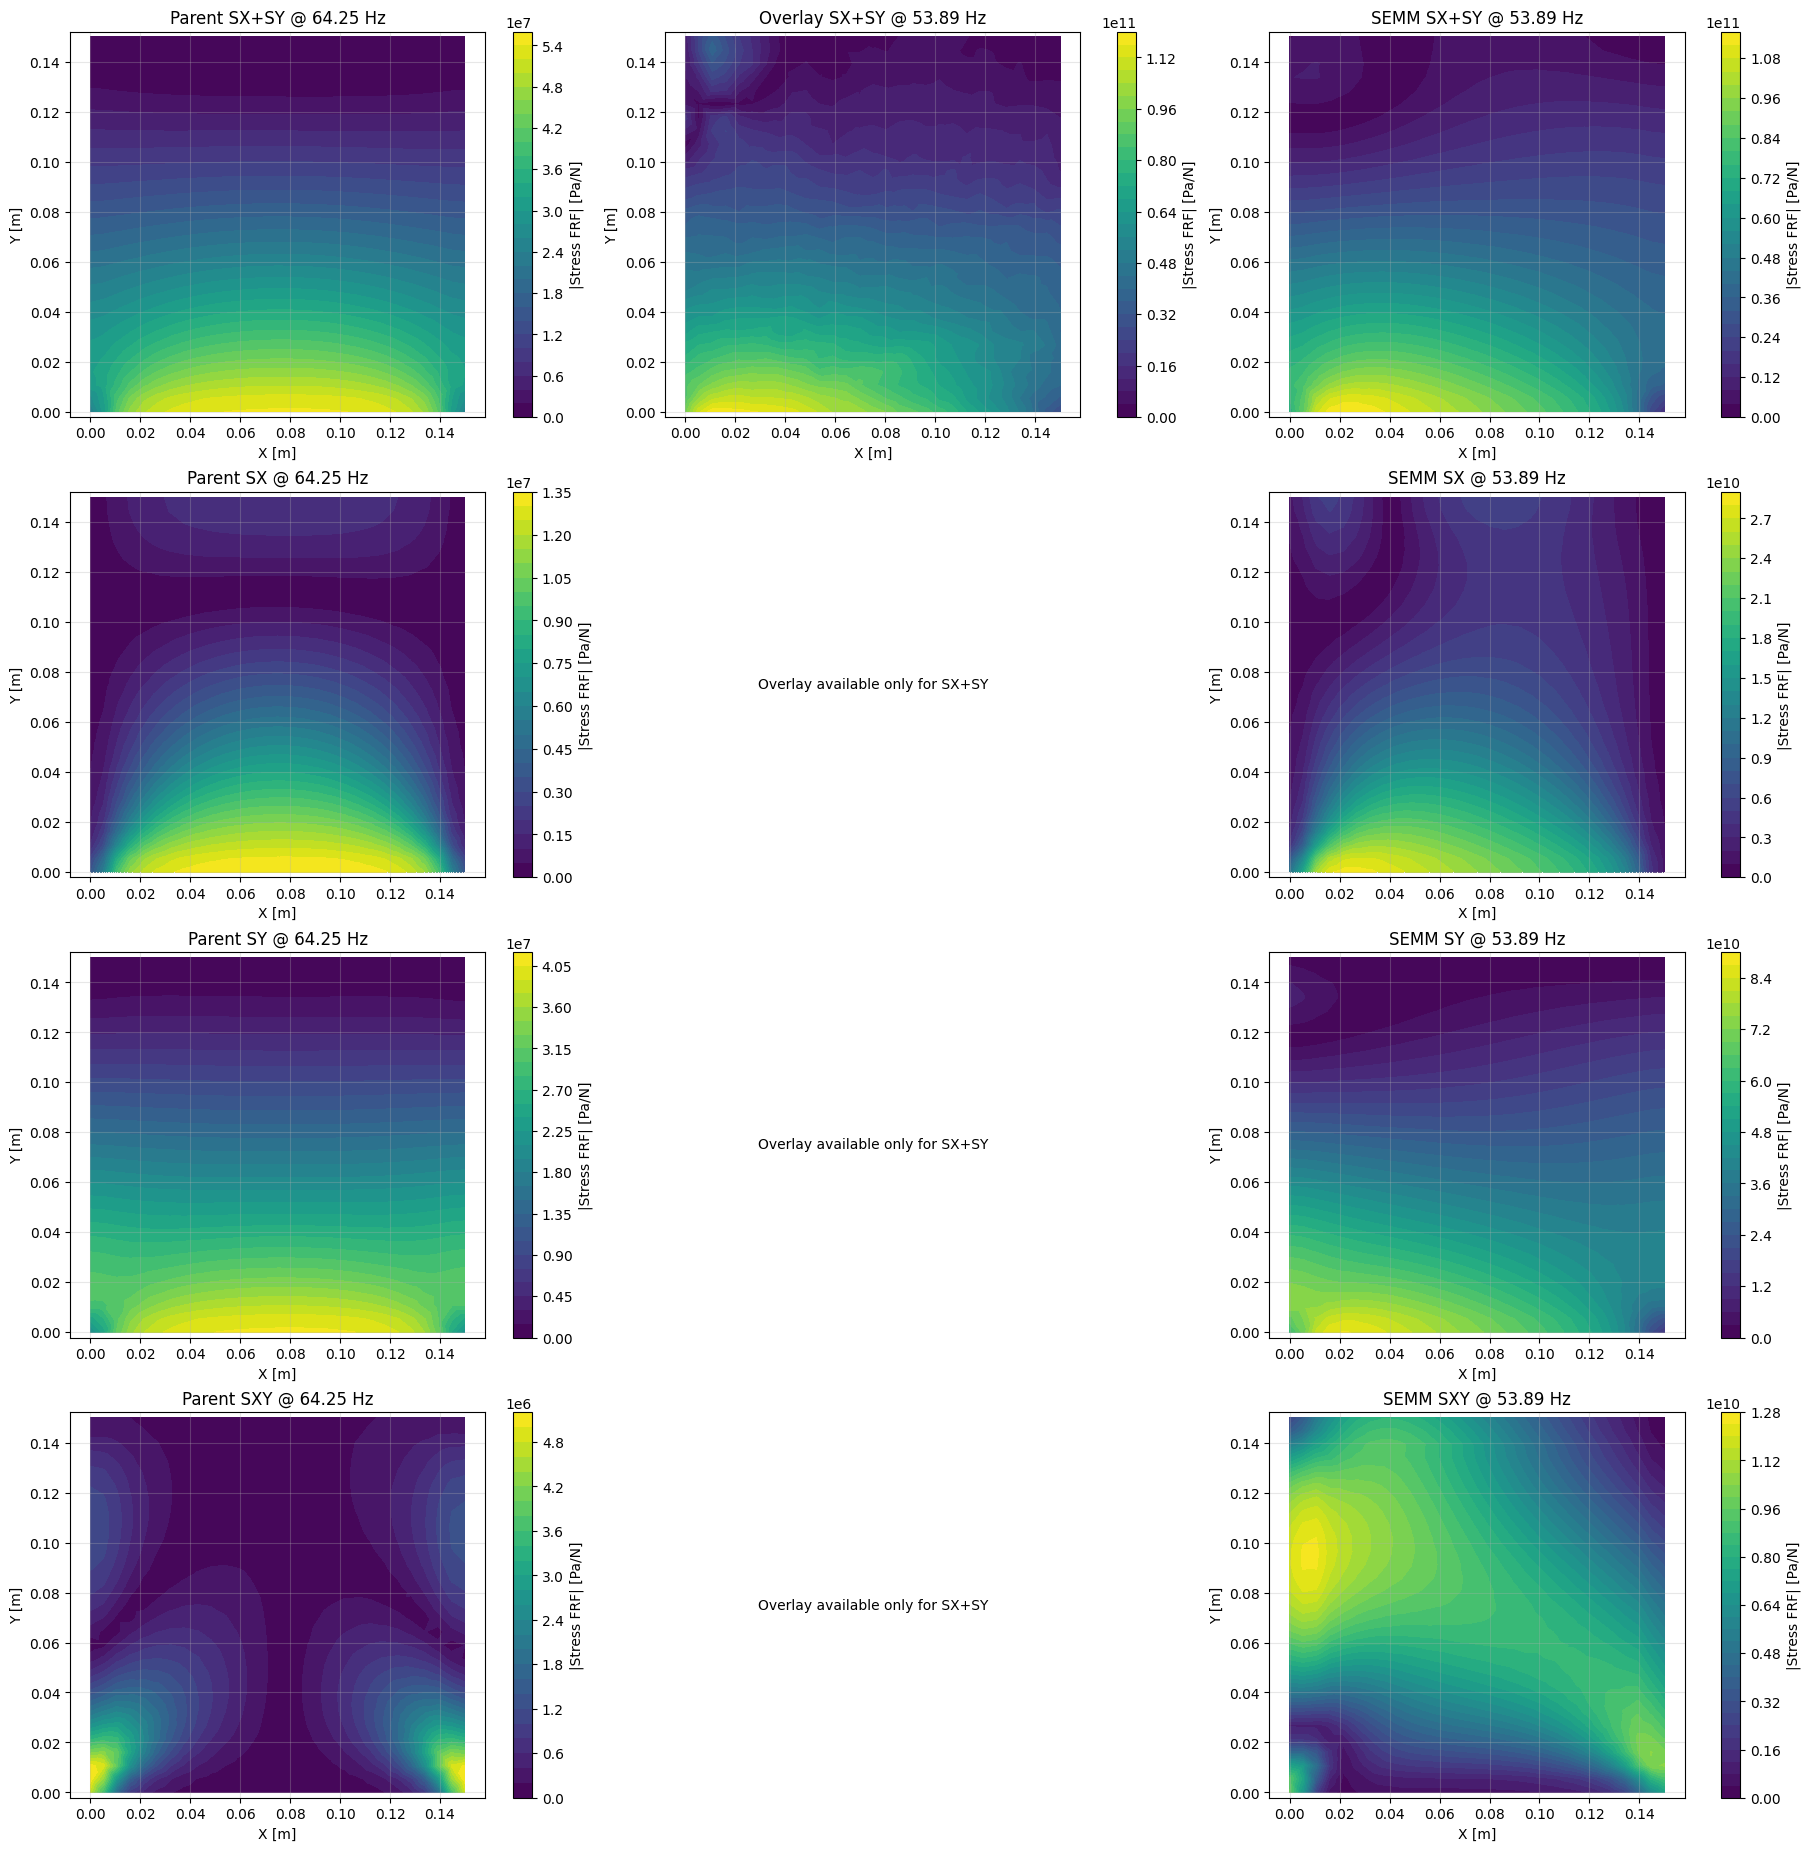

Band: Peak 2 (~150-200 Hz) [130.0, 220.0] Hz


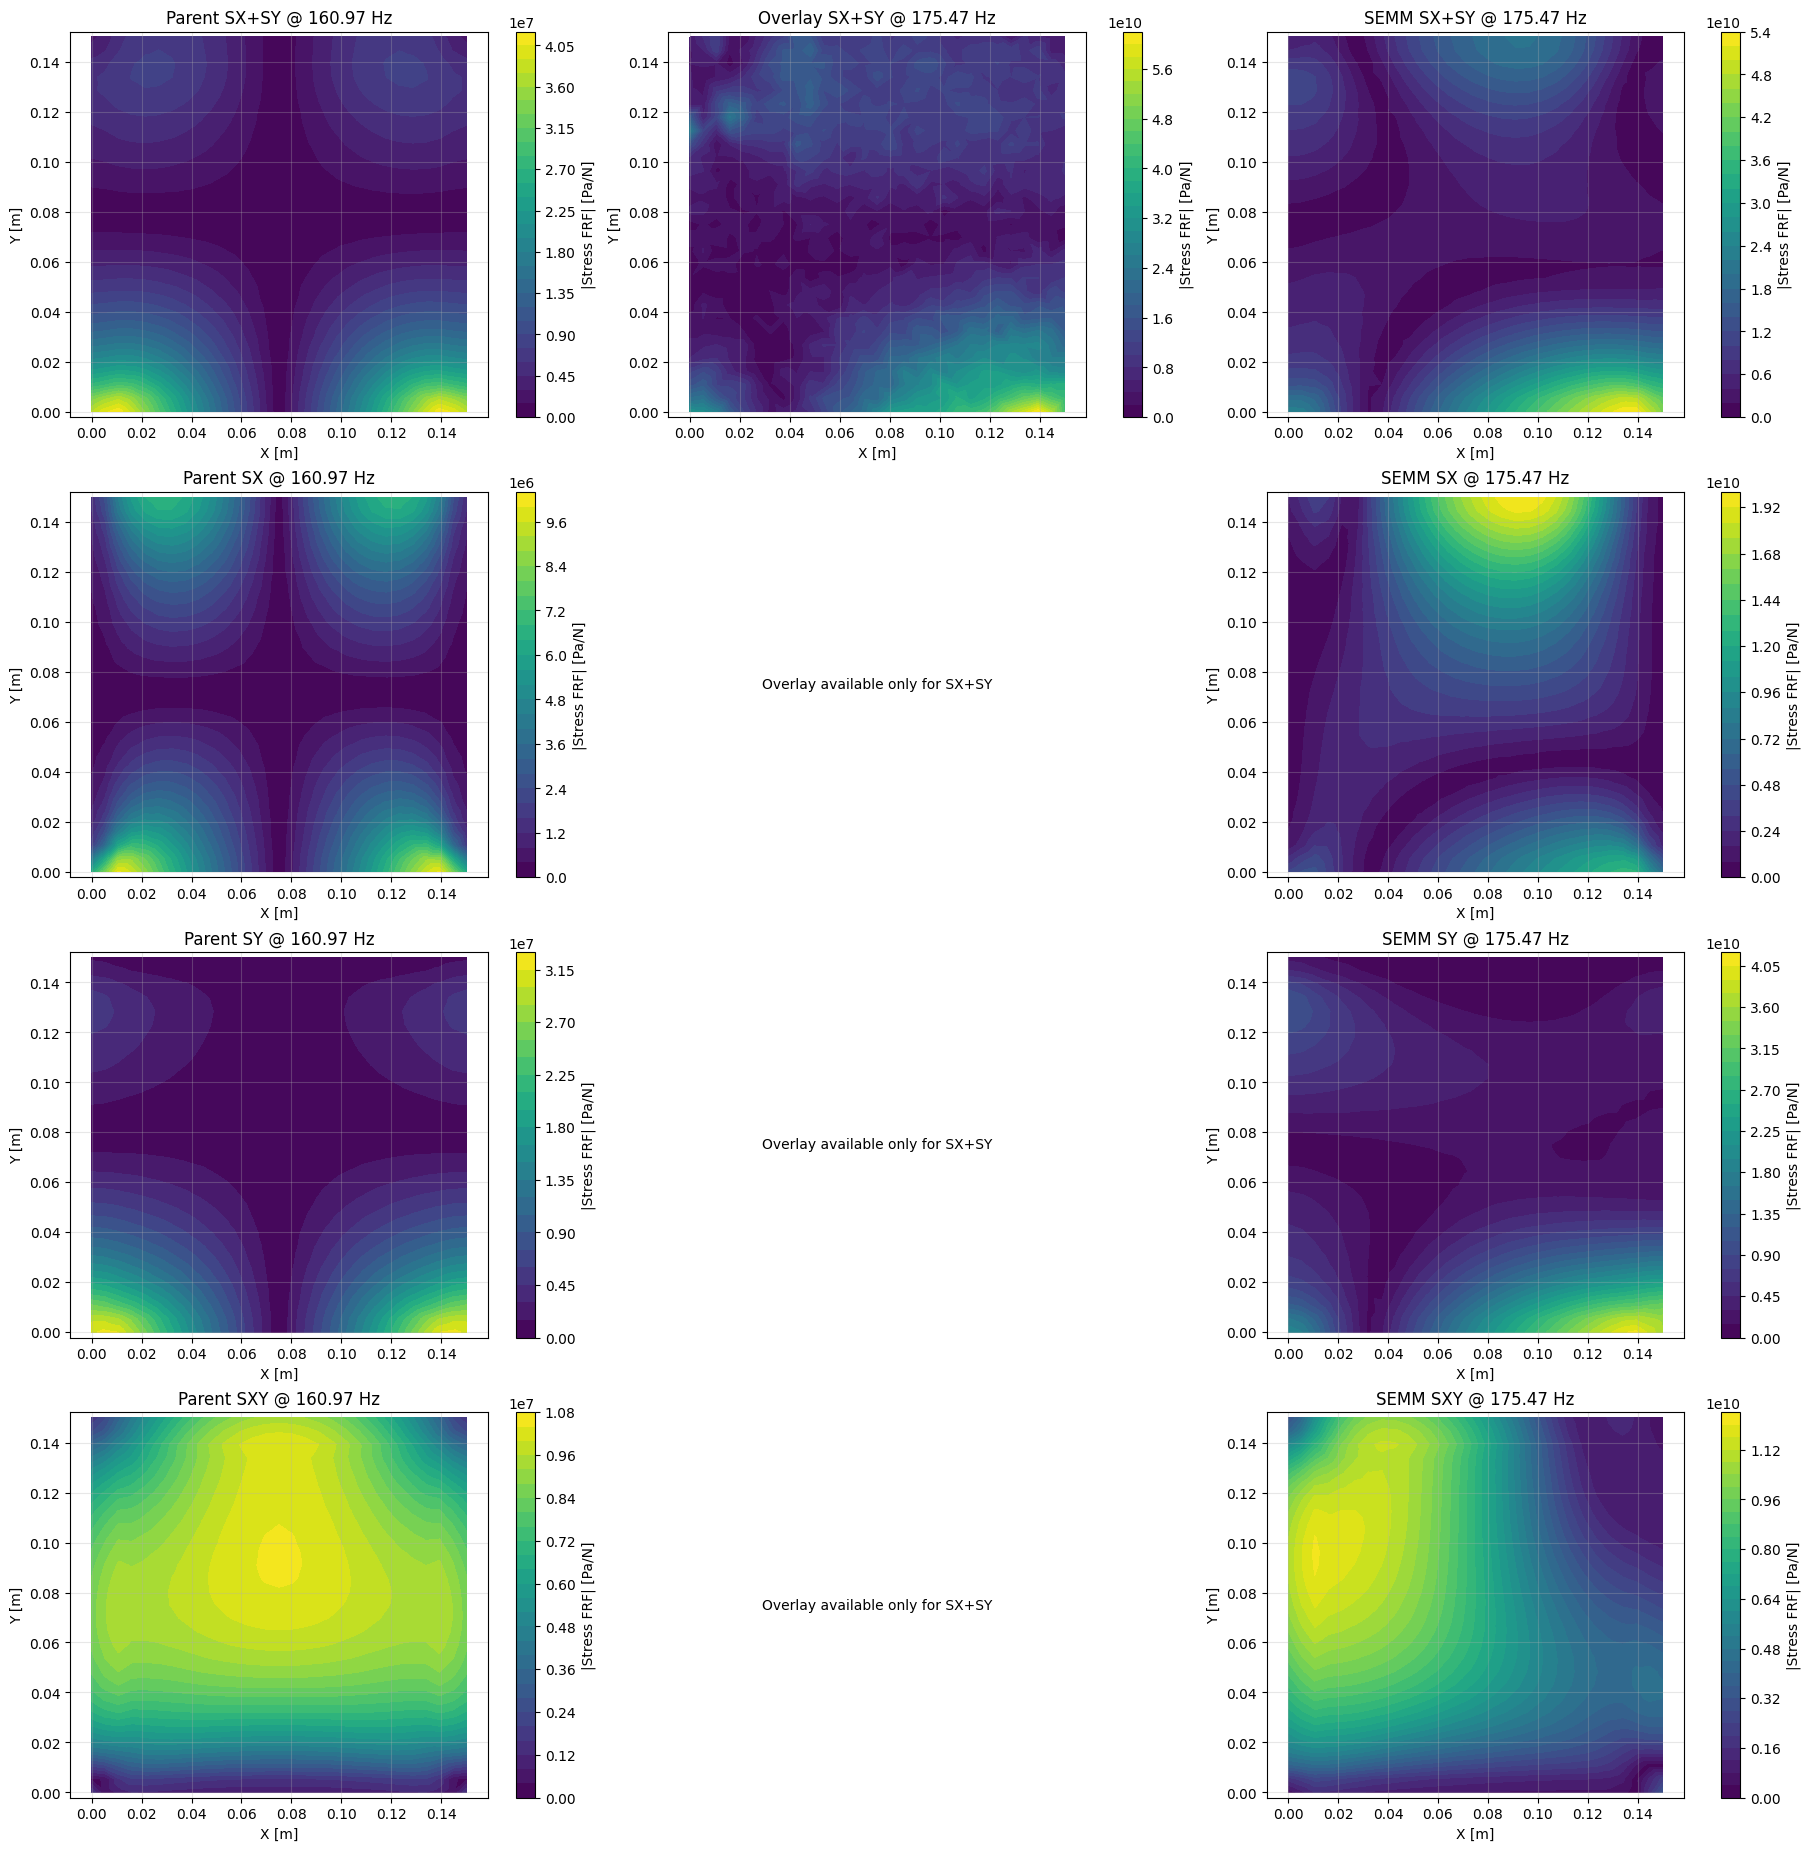

In [13]:

# Stage-1 all-components maps for both target resonance bands
COMPONENT_SEQUENCE = [
    (3, 'SX+SY', True),
    (0, 'SX', False),
    (1, 'SY', False),
    (2, 'SXY', False),
]

CASE_ALL_IDX = min(5, Y_final2.shape[2] - 1)
overlay_all = np.asarray(Y_camera[:, :, CASE_ALL_IDX])

for band in PEAK_BANDS:
    print('=' * 90)
    print(f"Band: {band['name']} [{band['fmin']:.1f}, {band['fmax']:.1f}] Hz")

    nrows = len(COMPONENT_SEQUENCE)
    fig, axes = plt.subplots(nrows, 3, figsize=(18, 4.6 * nrows), constrained_layout=True)
    if nrows == 1:
        axes = np.asarray([axes])

    for r, (comp, comp_name, has_overlay) in enumerate(COMPONENT_SEQUENCE):
        parent_all = np.asarray(Y_final2[:, comp::4, CASE_ALL_IDX])
        semm_all = np.asarray(Y_SEMM[:, comp::4, CASE_ALL_IDX])

        parent_metric = np.sqrt(np.mean(np.abs(parent_all) ** 2, axis=1))
        semm_metric = np.sqrt(np.mean(np.abs(semm_all) ** 2, axis=1))
        k_parent = pick_peak_idx_in_range(parent_metric, freq_axis, band['fmin'], band['fmax'])
        k_semm = pick_peak_idx_in_range(semm_metric, freq_axis, band['fmin'], band['fmax'])

        field_parent = np.abs(parent_all[k_parent])
        field_semm = np.abs(semm_all[k_semm])

        c0 = axes[r, 0].tricontourf(node_coords[:, 0], node_coords[:, 1], field_parent, levels=30)
        fig.colorbar(c0, ax=axes[r, 0], label='|Stress FRF| [Pa/N]')
        axes[r, 0].set_title(f"Parent {comp_name} @ {freq_axis[k_parent]:.2f} Hz")
        axes[r, 0].set_xlabel('X [m]'); axes[r, 0].set_ylabel('Y [m]'); axes[r, 0].axis('equal'); axes[r, 0].grid(True, alpha=0.3)

        if has_overlay:
            overlay_metric = np.sqrt(np.mean(np.abs(overlay_all) ** 2, axis=1))
            k_overlay = pick_peak_idx_in_range(overlay_metric, freq_axis, band['fmin'], band['fmax'])
            field_overlay = np.abs(overlay_all[k_overlay])
            c1 = axes[r, 1].tricontourf(camera_positions[:, 0], camera_positions[:, 1], field_overlay, levels=30)
            fig.colorbar(c1, ax=axes[r, 1], label='|Stress FRF| [Pa/N]')
            axes[r, 1].set_title(f"Overlay {comp_name} @ {freq_axis[k_overlay]:.2f} Hz")
            axes[r, 1].set_xlabel('X [m]'); axes[r, 1].set_ylabel('Y [m]'); axes[r, 1].axis('equal'); axes[r, 1].grid(True, alpha=0.3)
        else:
            axes[r, 1].axis('off')
            axes[r, 1].text(0.5, 0.5, 'Overlay available only for SX+SY', ha='center', va='center', transform=axes[r, 1].transAxes)

        c2 = axes[r, 2].tricontourf(node_coords[:, 0], node_coords[:, 1], field_semm, levels=30)
        fig.colorbar(c2, ax=axes[r, 2], label='|Stress FRF| [Pa/N]')
        axes[r, 2].set_title(f"SEMM {comp_name} @ {freq_axis[k_semm]:.2f} Hz")
        axes[r, 2].set_xlabel('X [m]'); axes[r, 2].set_ylabel('Y [m]'); axes[r, 2].axis('equal'); axes[r, 2].grid(True, alpha=0.3)

    plt.show()



In [14]:

# Stage-1 frequency heatmaps disabled per request.
print('Stage-1 frequency heatmaps disabled per request.')



Stage-1 frequency heatmaps disabled per request.


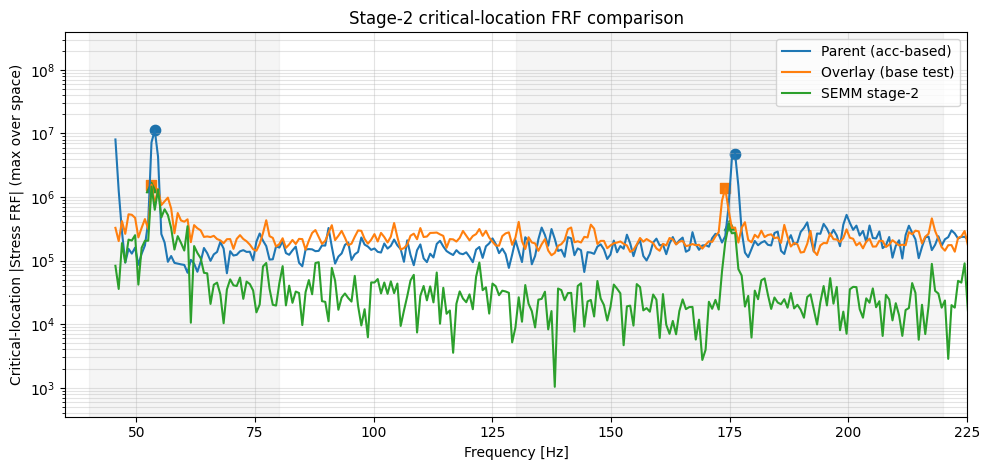

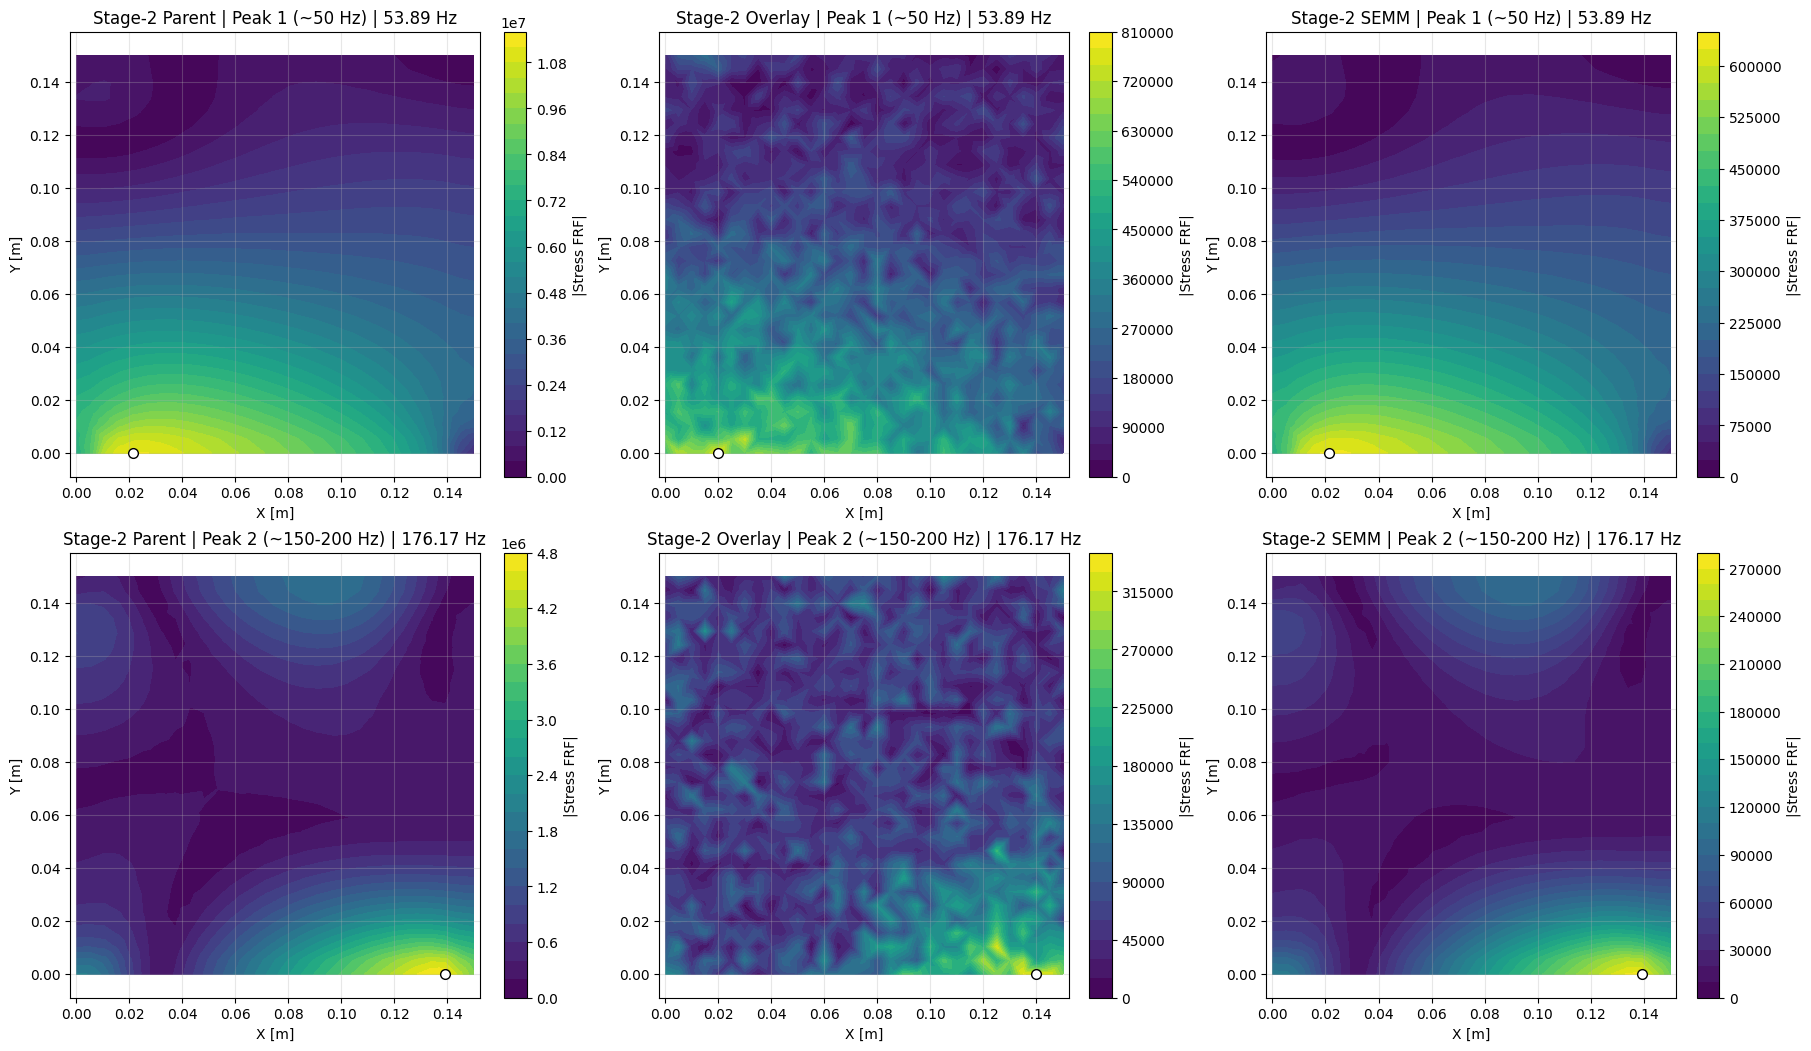

Peak 1 (~50 Hz): f_parent_peak=53.886 Hz | reference node=5 | overlay nearest pix=903
Peak 2 (~150-200 Hz): f_parent_peak=176.166 Hz | reference node=27 | overlay nearest pix=927


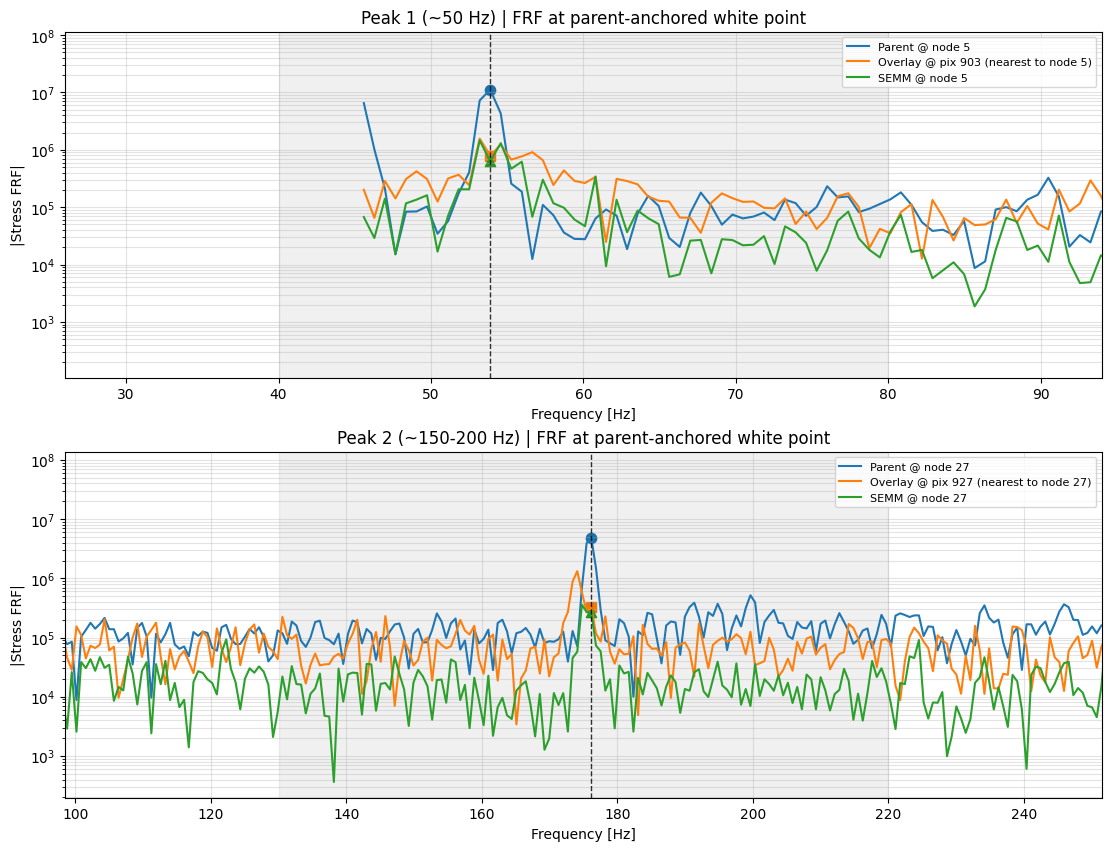

In [15]:
# Stage-2 FRF comparison + stage-2 maps for both target resonances
required_stage2 = ['Y_parent_acc', 'Y_overlay_base', 'Y_SEMM_stage2', 'camera_positions_stage2', 'diag_cam_stage2']
missing_stage2 = [k for k in required_stage2 if k not in stage2_data]
if missing_stage2:
    raise RuntimeError(f"Missing stage-2 keys for plotting: {missing_stage2}. Run Stage 2 cells first.")

Y_parent_acc = np.asarray(stage2_data['Y_parent_acc'])
Y_overlay_base = np.asarray(stage2_data['Y_overlay_base'])
Y_SEMM_stage2 = np.asarray(stage2_data['Y_SEMM_stage2'])
camera_positions_stage2 = np.asarray(stage2_data['camera_positions_stage2'])

COMP2 = COMPONENT_OVERLAY
parent2 = np.asarray(Y_parent_acc[:, COMP2::4, 0])
overlay2 = np.asarray(Y_overlay_base[:, :, 0])
semm2 = np.asarray(Y_SEMM_stage2[:, COMP2::4, 0])

abs_parent2 = np.abs(parent2)
abs_overlay2 = np.abs(overlay2)
abs_semm2 = np.abs(semm2)

# Critical-location FRF: at each frequency, use the highest-amplitude spatial point.
idx_parent2 = np.argmax(abs_parent2, axis=1)
idx_overlay2 = np.argmax(abs_overlay2, axis=1)
idx_semm2 = np.argmax(abs_semm2, axis=1)

metric_parent2 = abs_parent2[np.arange(len(freq_axis)), idx_parent2]
metric_overlay2 = abs_overlay2[np.arange(len(freq_axis)), idx_overlay2]
metric_semm2 = abs_semm2[np.arange(len(freq_axis)), idx_semm2]

# FRF summary with both peak markers
peak_parent2 = pick_peaks_for_bands(metric_parent2, freq_axis, PEAK_BANDS)
peak_overlay2 = pick_peaks_for_bands(metric_overlay2, freq_axis, PEAK_BANDS)
peak_semm2 = pick_peaks_for_bands(metric_semm2, freq_axis, PEAK_BANDS)

plt.figure(figsize=(10, 4.8))
plt.semilogy(freq_axis, np.maximum(metric_parent2, 1e-30), label='Parent (acc-based)')
plt.semilogy(freq_axis, np.maximum(metric_overlay2, 1e-30), label='Overlay (base test)')
plt.semilogy(freq_axis, np.maximum(metric_semm2, 1e-30), label='SEMM stage-2')

for j, band in enumerate(PEAK_BANDS):
    kp = peak_parent2[j][3]
    ko = peak_overlay2[j][3]
    ks = peak_semm2[j][3]
    plt.scatter([freq_axis[kp]], [metric_parent2[kp]], marker='o', color='C0', s=55)
    plt.scatter([freq_axis[ko]], [metric_overlay2[ko]], marker='s', color='C1', s=55)
    plt.scatter([freq_axis[ks]], [metric_semm2[ks]], marker='^', color='C2', s=55)
    plt.axvspan(band['fmin'], band['fmax'], color='k', alpha=0.04)

plt.xlim(min(b['fmin'] for b in PEAK_BANDS) - 5.0, max(b['fmax'] for b in PEAK_BANDS) + 5.0)
plt.xlabel('Frequency [Hz]')
plt.ylabel('Critical-location |Stress FRF| (max over space)')
plt.title('Stage-2 critical-location FRF comparison')
plt.grid(True, which='both', alpha=0.35)
plt.legend()
plt.tight_layout()
plt.show()

# 2 x 3 maps (one row per band)
fig, axes = plt.subplots(len(PEAK_BANDS), 3, figsize=(18, 5.2 * len(PEAK_BANDS)), constrained_layout=True)
if len(PEAK_BANDS) == 1:
    axes = np.asarray([axes])

for r, band in enumerate(PEAK_BANDS):
    # Anchor each band to Parent peak frequency and Parent critical node.
    kp = peak_parent2[r][3]
    ip_ref = int(idx_parent2[kp])

    # Overlay uses nearest camera pixel to the same physical parent node location.
    d2_cam = np.sum((camera_positions_stage2[:, :2] - node_coords[ip_ref, :2]) ** 2, axis=1)
    io_ref = int(np.argmin(d2_cam))

    field_parent2 = abs_parent2[kp]
    field_overlay2 = abs_overlay2[kp]
    field_semm2 = abs_semm2[kp]

    c0 = axes[r, 0].tricontourf(node_coords[:, 0], node_coords[:, 1], field_parent2, levels=30)
    fig.colorbar(c0, ax=axes[r, 0], label='|Stress FRF|')
    axes[r, 0].set_title(f"Stage-2 Parent | {band['name']} | {freq_axis[kp]:.2f} Hz")
    axes[r, 0].set_xlabel('X [m]'); axes[r, 0].set_ylabel('Y [m]'); axes[r, 0].axis('equal'); axes[r, 0].grid(True, alpha=0.3)
    axes[r, 0].plot(node_coords[ip_ref, 0], node_coords[ip_ref, 1], 'wo', ms=7, mec='k', mew=1.0)

    c1 = axes[r, 1].tricontourf(camera_positions_stage2[:, 0], camera_positions_stage2[:, 1], field_overlay2, levels=30)
    fig.colorbar(c1, ax=axes[r, 1], label='|Stress FRF|')
    axes[r, 1].set_title(f"Stage-2 Overlay | {band['name']} | {freq_axis[kp]:.2f} Hz")
    axes[r, 1].set_xlabel('X [m]'); axes[r, 1].set_ylabel('Y [m]'); axes[r, 1].axis('equal'); axes[r, 1].grid(True, alpha=0.3)
    axes[r, 1].plot(camera_positions_stage2[io_ref, 0], camera_positions_stage2[io_ref, 1], 'wo', ms=7, mec='k', mew=1.0)

    c2 = axes[r, 2].tricontourf(node_coords[:, 0], node_coords[:, 1], field_semm2, levels=30)
    fig.colorbar(c2, ax=axes[r, 2], label='|Stress FRF|')
    axes[r, 2].set_title(f"Stage-2 SEMM | {band['name']} | {freq_axis[kp]:.2f} Hz")
    axes[r, 2].set_xlabel('X [m]'); axes[r, 2].set_ylabel('Y [m]'); axes[r, 2].axis('equal'); axes[r, 2].grid(True, alpha=0.3)
    axes[r, 2].plot(node_coords[ip_ref, 0], node_coords[ip_ref, 1], 'wo', ms=7, mec='k', mew=1.0)

plt.show()

for j, band in enumerate(PEAK_BANDS):
    kp = peak_parent2[j][3]
    ip_ref = int(idx_parent2[kp])
    d2_cam = np.sum((camera_positions_stage2[:, :2] - node_coords[ip_ref, :2]) ** 2, axis=1)
    io_ref = int(np.argmin(d2_cam))

    print(
        f"{band['name']}: f_parent_peak={freq_axis[kp]:.3f} Hz | "
        f"reference node={ip_ref} | overlay nearest pix={io_ref}"
    )

# FRF traces at detected white-point locations (one subplot per target peak)
fig, axs = plt.subplots(len(PEAK_BANDS), 1, figsize=(11, 4.2 * len(PEAK_BANDS)), constrained_layout=True)
if len(PEAK_BANDS) == 1:
    axs = [axs]

for j, band in enumerate(PEAK_BANDS):
    ax = axs[j]

    kp = peak_parent2[j][3]
    ip_ref = int(idx_parent2[kp])
    d2_cam = np.sum((camera_positions_stage2[:, :2] - node_coords[ip_ref, :2]) ** 2, axis=1)
    io_ref = int(np.argmin(d2_cam))

    tr_parent = np.maximum(abs_parent2[:, ip_ref], 1e-30)
    tr_overlay = np.maximum(abs_overlay2[:, io_ref], 1e-30)
    tr_semm = np.maximum(abs_semm2[:, ip_ref], 1e-30)

    ax.semilogy(freq_axis, tr_parent, label=f'Parent @ node {ip_ref}')
    ax.semilogy(freq_axis, tr_overlay, label=f'Overlay @ pix {io_ref} (nearest to node {ip_ref})')
    ax.semilogy(freq_axis, tr_semm, label=f'SEMM @ node {ip_ref}')

    ax.scatter([freq_axis[kp]], [tr_parent[kp]], marker='o', color='C0', s=55)
    ax.scatter([freq_axis[kp]], [tr_overlay[kp]], marker='s', color='C1', s=55)
    ax.scatter([freq_axis[kp]], [tr_semm[kp]], marker='^', color='C2', s=55)

    pad = max(5.0, 0.35 * (band['fmax'] - band['fmin']))
    ax.set_xlim(band['fmin'] - pad, band['fmax'] + pad)
    ax.axvspan(band['fmin'], band['fmax'], color='k', alpha=0.06)
    ax.axvline(freq_axis[kp], color='k', ls='--', lw=1.0, alpha=0.8)
    ax.set_title(f"{band['name']} | FRF at parent-anchored white point")
    ax.set_xlabel('Frequency [Hz]')
    ax.set_ylabel('|Stress FRF|')
    ax.grid(True, which='both', alpha=0.35)
    ax.legend(fontsize=8)

plt.show()


In [16]:

# Stage-2 frequency heatmaps disabled per request.
print('Stage-2 frequency heatmaps disabled per request.')



Stage-2 frequency heatmaps disabled per request.


In [17]:
# ---------------- SAVE ----------------
pipe.save_outputs()
print('Saved to:', pipe.state['meta'].get('last_output_dir'))


Saved to: C:\Users\jasas\Work\Clanki\Clanek_2\Trigger_and_acquisition\dual_stage_base_pipeline\outputs\20260223_083351


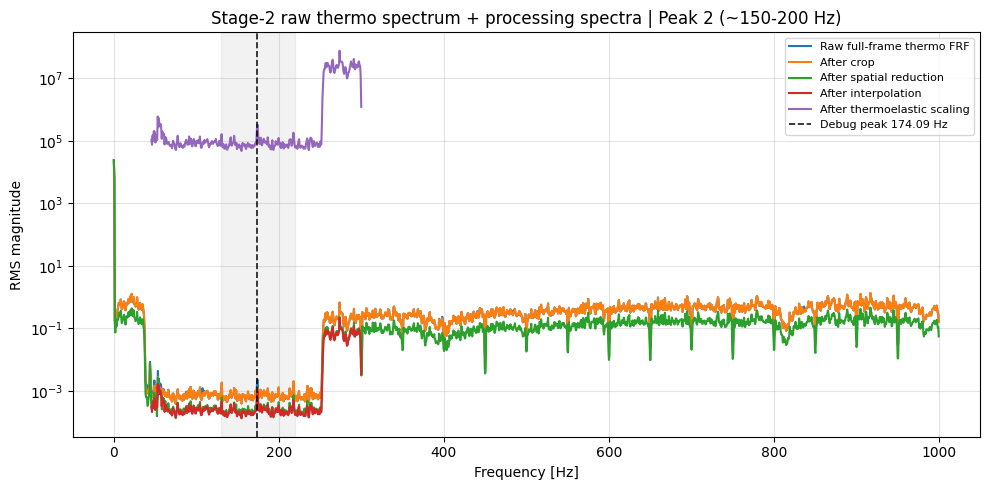

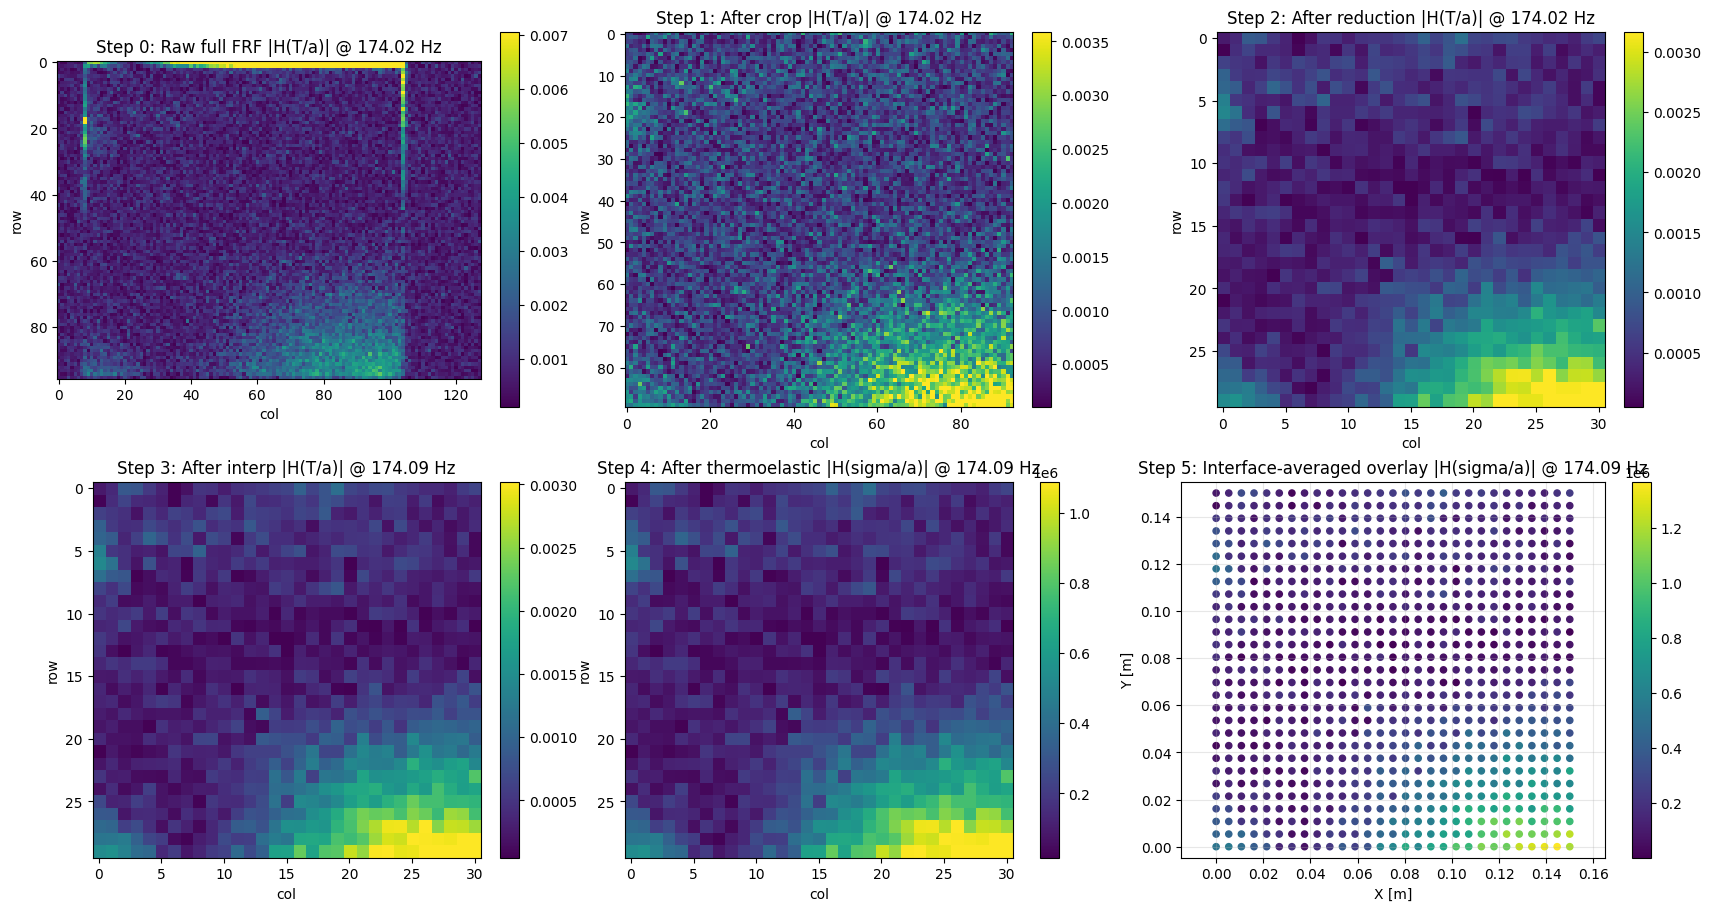

Debug peak band: {'name': 'Peak 2 (~150-200 Hz)', 'fmin': 130.0, 'fmax': 220.0}
Chosen peak frequency: 174.093 Hz (k=186)
Shapes:
  raw full: (1667, 96, 128) crop: (1667, 90, 93) reduced: (1667, 30, 31)
  interp: (369, 30, 31) stress: (369, 30, 31) overlay_if: (369, 841)
Stage-2 crop used: {'row_start': 3, 'row_end': 93, 'col_start': 10, 'col_end': 103}


In [18]:
# ---------------- STAGE-2 OVERLAY DEBUG (RAW -> PROCESSED AT SAME PEAK) ----------------
stage1_data = pipe.state.get('stage1', {})
stage2_data = pipe.state.get('stage2', {})

req1 = ['freqs', 'component_overlay', 'node_coords']
req2 = ['images', 'acc_ref', 'fs_acc', 'fs_ir', 'Y_overlay_base', 'Y_overlay_base_num']
miss1 = [k for k in req1 if k not in stage1_data]
miss2 = [k for k in req2 if k not in stage2_data]
if miss1 or miss2:
    raise RuntimeError(f"Missing data for debug plotting. stage1={miss1}, stage2={miss2}")

freq_axis = np.asarray(stage1_data['freqs'], dtype=float)
COMP2 = int(stage1_data['component_overlay'])
node_coords = np.asarray(stage1_data['node_coords'], dtype=float)

images_raw = np.asarray(stage2_data['images'])
acc_ref = np.asarray(stage2_data['acc_ref'], dtype=float)
fs_acc = float(stage2_data['fs_acc'])
fs_ir = float(stage2_data['fs_ir'])

stage2_crop = stage2_data.get('stage2_crop_used', stage1_data.get('stage1_crop', pipe.stage1_cfg.crop))
reduce_factor = pipe.stage2_cfg.reduce_factor if pipe.stage2_cfg.reduce_factor is not None else pipe.stage1_cfg.reduce_factor
n_segments = int(pipe.stage2_cfg.n_segments)
cam_to_stress = float(stage1_data.get('cam_to_stress_factor', pipe._camera_to_stress_factor_pa_per_k()))

# Choose which peak band to debug (0: first peak, 1: second peak)
DEBUG_PEAK_BAND_INDEX = 1
if 'PEAK_BANDS' in globals() and len(PEAK_BANDS) > 0:
    bands_local = PEAK_BANDS
else:
    bands_local = [
        {'name': 'Peak 1 (~50 Hz)', 'fmin': 40.0, 'fmax': 80.0},
        {'name': 'Peak 2 (~150-200 Hz)', 'fmin': 130.0, 'fmax': 220.0},
    ]
DEBUG_PEAK_BAND_INDEX = int(np.clip(DEBUG_PEAK_BAND_INDEX, 0, len(bands_local) - 1))

# Overlay critical metric to pick the debug peak frequency.
overlay2 = np.asarray(stage2_data['Y_overlay_base'][:, :, 0])
metric_overlay2 = np.max(np.abs(overlay2), axis=1)

band = bands_local[DEBUG_PEAK_BAND_INDEX]
mask_band = (freq_axis >= float(band['fmin'])) & (freq_axis <= float(band['fmax']))
if not np.any(mask_band):
    raise ValueError(f"No frequencies in debug band [{band['fmin']}, {band['fmax']}] Hz")

if 'pick_peak_idx' in globals():
    idx_local = np.where(mask_band)[0]
    y_local = np.nan_to_num(metric_overlay2[mask_band], nan=-np.inf, posinf=-np.inf, neginf=-np.inf)
    k_peak = int(idx_local[np.argmax(y_local)])
else:
    idx_local = np.where(mask_band)[0]
    y_local = np.nan_to_num(metric_overlay2[mask_band], nan=-np.inf, posinf=-np.inf, neginf=-np.inf)
    k_peak = int(idx_local[np.argmax(y_local)])

f_peak = float(freq_axis[k_peak])

# Step 0: raw full-frame FRF (temperature/acc)
freq_raw, H_raw_full = pipe.frf_ir_h1(acc_ref, fs_acc, images_raw, fs_ir, n_segments)
k_raw = int(np.argmin(np.abs(freq_raw - f_peak)))
map_raw_full = np.abs(H_raw_full[k_raw])

# Step 1: cropped FRF (temperature/acc)
images_crop = pipe.crop_video(images_raw, stage2_crop)
freq_crop, H_crop = pipe.frf_ir_h1(acc_ref, fs_acc, images_crop, fs_ir, n_segments)
k_crop = int(np.argmin(np.abs(freq_crop - f_peak)))
map_crop = np.abs(H_crop[k_crop])

# Step 2: spatial reduction
H_red = pipe.reduce_resolution(H_crop, reduce_factor, mode='crop')
map_red = np.abs(H_red[k_crop])
rows_red, cols_red = H_red.shape[1:]

# Step 3: interpolate to stage-1 frequency axis
H_red_flat = H_red.reshape(len(freq_crop), rows_red * cols_red)
H_interp_flat = pipe.interp_complex_to_target(freq_crop, H_red_flat, freq_axis)
H_interp = H_interp_flat.reshape(len(freq_axis), rows_red, cols_red)
map_interp = np.abs(H_interp[k_peak])

# Step 4: thermoelastic conversion (stress/acc)
H_stress = cam_to_stress * H_interp
map_stress = np.abs(H_stress[k_peak])

# Step 5: interface-averaged overlay on numerical interface DoFs
overlay_num = np.asarray(stage2_data['Y_overlay_base_num'][:, :, 0])
map_overlay_if = np.abs(overlay_num[k_peak])
b_nodes2 = np.asarray(stage2_data.get('b_nodes_stage2', []), dtype=int)

# Raw thermo frequency spectrum + processing spectra
spec_raw = np.sqrt(np.mean(np.abs(H_raw_full) ** 2, axis=(1, 2)))
spec_crop = np.sqrt(np.mean(np.abs(H_crop) ** 2, axis=(1, 2)))
spec_red = np.sqrt(np.mean(np.abs(H_red) ** 2, axis=(1, 2)))
spec_interp = np.sqrt(np.mean(np.abs(H_interp) ** 2, axis=(1, 2)))
spec_stress = np.sqrt(np.mean(np.abs(H_stress) ** 2, axis=(1, 2)))

plt.figure(figsize=(10, 5))
plt.semilogy(freq_raw, np.maximum(spec_raw, 1e-30), label='Raw full-frame thermo FRF')
plt.semilogy(freq_crop, np.maximum(spec_crop, 1e-30), label='After crop')
plt.semilogy(freq_crop, np.maximum(spec_red, 1e-30), label='After spatial reduction')
plt.semilogy(freq_axis, np.maximum(spec_interp, 1e-30), label='After interpolation')
plt.semilogy(freq_axis, np.maximum(spec_stress, 1e-30), label='After thermoelastic scaling')
plt.axvline(f_peak, color='k', ls='--', lw=1.2, alpha=0.9, label=f'Debug peak {f_peak:.2f} Hz')
plt.axvspan(float(band['fmin']), float(band['fmax']), color='k', alpha=0.05)
plt.xlabel('Frequency [Hz]')
plt.ylabel('RMS magnitude')
plt.title(f"Stage-2 raw thermo spectrum + processing spectra | {band['name']}")
plt.grid(True, which='both', alpha=0.35)
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()


def _imshow_pct(ax, Z, title, cmap='viridis'):
    z = np.asarray(Z, dtype=float)
    finite = np.isfinite(z)
    if np.any(finite):
        vmin, vmax = np.percentile(z[finite], [1, 99])
        if not np.isfinite(vmin) or not np.isfinite(vmax) or vmin == vmax:
            vmin, vmax = None, None
    else:
        vmin, vmax = None, None
    im = ax.imshow(z, origin='upper', cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_title(title)
    ax.set_xlabel('col')
    ax.set_ylabel('row')
    return im


fig, axes = plt.subplots(2, 3, figsize=(17, 9), constrained_layout=True)

im0 = _imshow_pct(axes[0, 0], map_raw_full, f"Step 0: Raw full FRF |H(T/a)| @ {freq_raw[k_raw]:.2f} Hz")
fig.colorbar(im0, ax=axes[0, 0], fraction=0.046, pad=0.04)

im1 = _imshow_pct(axes[0, 1], map_crop, f"Step 1: After crop |H(T/a)| @ {freq_crop[k_crop]:.2f} Hz")
fig.colorbar(im1, ax=axes[0, 1], fraction=0.046, pad=0.04)

im2 = _imshow_pct(axes[0, 2], map_red, f"Step 2: After reduction |H(T/a)| @ {freq_crop[k_crop]:.2f} Hz")
fig.colorbar(im2, ax=axes[0, 2], fraction=0.046, pad=0.04)

im3 = _imshow_pct(axes[1, 0], map_interp, f"Step 3: After interp |H(T/a)| @ {freq_axis[k_peak]:.2f} Hz")
fig.colorbar(im3, ax=axes[1, 0], fraction=0.046, pad=0.04)

im4 = _imshow_pct(axes[1, 1], map_stress, f"Step 4: After thermoelastic |H(sigma/a)| @ {freq_axis[k_peak]:.2f} Hz")
fig.colorbar(im4, ax=axes[1, 1], fraction=0.046, pad=0.04)

ax_if = axes[1, 2]
if b_nodes2.size > 0 and b_nodes2.size == map_overlay_if.size:
    sc = ax_if.scatter(node_coords[b_nodes2, 0], node_coords[b_nodes2, 1], c=map_overlay_if, cmap='viridis', s=20)
    fig.colorbar(sc, ax=ax_if, fraction=0.046, pad=0.04)
    ax_if.set_title(f"Step 5: Interface-averaged overlay |H(sigma/a)| @ {freq_axis[k_peak]:.2f} Hz")
    ax_if.set_xlabel('X [m]')
    ax_if.set_ylabel('Y [m]')
    ax_if.axis('equal')
    ax_if.grid(True, alpha=0.3)
else:
    ax_if.text(0.05, 0.5, 'b_nodes_stage2 unavailable for interface plot', transform=ax_if.transAxes)
    ax_if.set_title('Step 5: Interface averaging')

plt.show()

print('Debug peak band:', band)
print(f'Chosen peak frequency: {f_peak:.3f} Hz (k={k_peak})')
print('Shapes:')
print('  raw full:', H_raw_full.shape, 'crop:', H_crop.shape, 'reduced:', H_red.shape)
print('  interp:', H_interp.shape, 'stress:', H_stress.shape, 'overlay_if:', overlay_num.shape)
print('Stage-2 crop used:', stage2_crop)


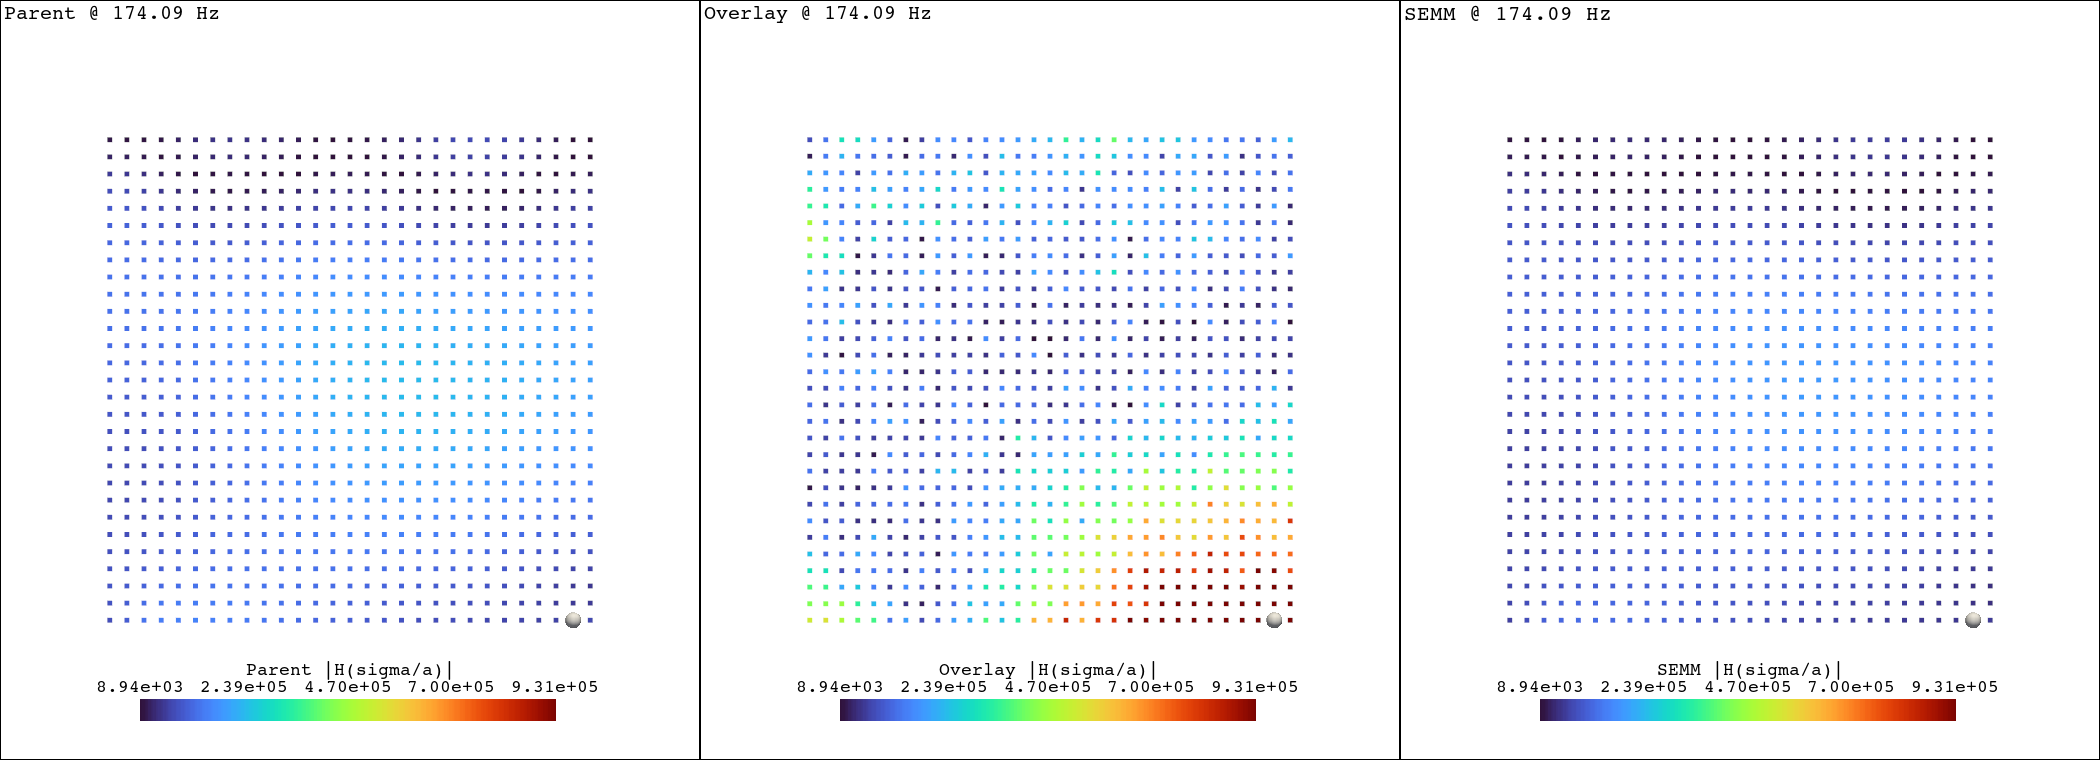

PyVista debug band: {'name': 'Peak 2 (~150-200 Hz)', 'fmin': 130.0, 'fmax': 220.0}
Overlay-selected peak: f=174.093 Hz (k=186)
Overlay critical pixel: 928 | nearest numerical node: 28


In [19]:
# ---------------- STAGE-2 PYVISTA DEBUG MAP (OVERLAY PEAK) ----------------
import numpy as np

try:
    import pyvista as pv
except Exception as exc:
    raise ImportError("PyVista is required for this cell. Install pyvista in your active environment.") from exc

stage1_data = pipe.state.get('stage1', {})
stage2_data = pipe.state.get('stage2', {})

req1 = ['freqs', 'component_overlay', 'node_coords']
req2 = ['Y_parent_acc', 'Y_overlay_base', 'Y_SEMM_stage2', 'camera_positions_stage2']
miss1 = [k for k in req1 if k not in stage1_data]
miss2 = [k for k in req2 if k not in stage2_data]
if miss1 or miss2:
    raise RuntimeError(f"Missing data for PyVista debug. stage1={miss1}, stage2={miss2}")

freq_axis = np.asarray(stage1_data['freqs'], dtype=float)
COMP2 = int(stage1_data['component_overlay'])
node_coords = np.asarray(stage1_data['node_coords'], dtype=float)
camera_positions_stage2 = np.asarray(stage2_data['camera_positions_stage2'], dtype=float)

parent2 = np.asarray(stage2_data['Y_parent_acc'][:, COMP2::4, 0])
overlay2 = np.asarray(stage2_data['Y_overlay_base'][:, :, 0])
semm2 = np.asarray(stage2_data['Y_SEMM_stage2'][:, COMP2::4, 0])

# choose peak band and detect from overlay
PYVISTA_PEAK_BAND_INDEX = 1
if 'PEAK_BANDS' in globals() and len(PEAK_BANDS) > 0:
    bands_local = PEAK_BANDS
else:
    bands_local = [
        {'name': 'Peak 1 (~50 Hz)', 'fmin': 40.0, 'fmax': 80.0},
        {'name': 'Peak 2 (~150-200 Hz)', 'fmin': 130.0, 'fmax': 220.0},
    ]
PYVISTA_PEAK_BAND_INDEX = int(np.clip(PYVISTA_PEAK_BAND_INDEX, 0, len(bands_local) - 1))

band = bands_local[PYVISTA_PEAK_BAND_INDEX]
metric_overlay2 = np.max(np.abs(overlay2), axis=1)
mask_band = (freq_axis >= float(band['fmin'])) & (freq_axis <= float(band['fmax']))
if not np.any(mask_band):
    raise ValueError(f"No frequencies in band [{band['fmin']}, {band['fmax']}] Hz")
idx_local = np.where(mask_band)[0]
y_local = np.nan_to_num(metric_overlay2[mask_band], nan=-np.inf, posinf=-np.inf, neginf=-np.inf)
k_peak = int(idx_local[np.argmax(y_local)])
f_peak = float(freq_axis[k_peak])

field_parent = np.abs(parent2[k_peak])
field_overlay = np.abs(overlay2[k_peak])
field_semm = np.abs(semm2[k_peak])

# overlay critical pixel and nearest numerical node
io = int(np.argmax(field_overlay))
d2_nodes = np.sum((node_coords[:, :2] - camera_positions_stage2[io, :2]) ** 2, axis=1)
ip_ref = int(np.argmin(d2_nodes))

# build meshes
semm_mesh_parent = pv.PolyData(node_coords.copy())
semm_mesh_parent['Parent |H(sigma/a)|'] = field_parent

camera_mesh = pv.PolyData(camera_positions_stage2.copy())
camera_mesh['Overlay |H(sigma/a)|'] = field_overlay

semm_mesh_semm = pv.PolyData(node_coords.copy())
semm_mesh_semm['SEMM |H(sigma/a)|'] = field_semm

highlight_node = pv.PolyData(node_coords[ip_ref].reshape(1, 3))
highlight_cam = pv.PolyData(camera_positions_stage2[io].reshape(1, 3))

# common color scale for visual comparability
all_vals = np.hstack([field_parent.ravel(), field_overlay.ravel(), field_semm.ravel()])
finite = np.isfinite(all_vals)
if np.any(finite):
    clim = tuple(np.percentile(all_vals[finite], [1, 99]).tolist())
else:
    clim = None

pv.set_jupyter_backend('static')
plotter = pv.Plotter(shape=(1, 3), notebook=True, window_size=(2100, 760))
scalar_bar_args = dict(position_x=0.2, position_y=0.05, fmt='%.2e')

plotter.subplot(0, 0)
plotter.add_mesh(
    semm_mesh_parent,
    scalars='Parent |H(sigma/a)|',
    cmap='turbo',
    show_edges=False,
    show_scalar_bar=True,
    scalar_bar_args=scalar_bar_args,
    clim=clim,
)
plotter.add_mesh(highlight_node, color='white', point_size=16, render_points_as_spheres=True)
plotter.add_text(f"Parent @ {f_peak:.2f} Hz", font_size=10)
plotter.view_xy()
plotter.reset_camera()

plotter.subplot(0, 1)
plotter.add_mesh(
    camera_mesh,
    scalars='Overlay |H(sigma/a)|',
    cmap='turbo',
    show_edges=False,
    show_scalar_bar=True,
    scalar_bar_args=scalar_bar_args,
    clim=clim,
)
plotter.add_mesh(highlight_cam, color='white', point_size=16, render_points_as_spheres=True)
plotter.add_text(f"Overlay @ {f_peak:.2f} Hz", font_size=10)
plotter.view_xy()
plotter.reset_camera()

plotter.subplot(0, 2)
plotter.add_mesh(
    semm_mesh_semm,
    scalars='SEMM |H(sigma/a)|',
    cmap='turbo',
    show_edges=False,
    show_scalar_bar=True,
    scalar_bar_args=scalar_bar_args,
    clim=clim,
)
plotter.add_mesh(highlight_node, color='white', point_size=16, render_points_as_spheres=True)
plotter.add_text(f"SEMM @ {f_peak:.2f} Hz", font_size=10)
plotter.view_xy()
plotter.reset_camera()

plotter.show()

print('PyVista debug band:', band)
print(f'Overlay-selected peak: f={f_peak:.3f} Hz (k={k_peak})')
print(f'Overlay critical pixel: {io} | nearest numerical node: {ip_ref}')


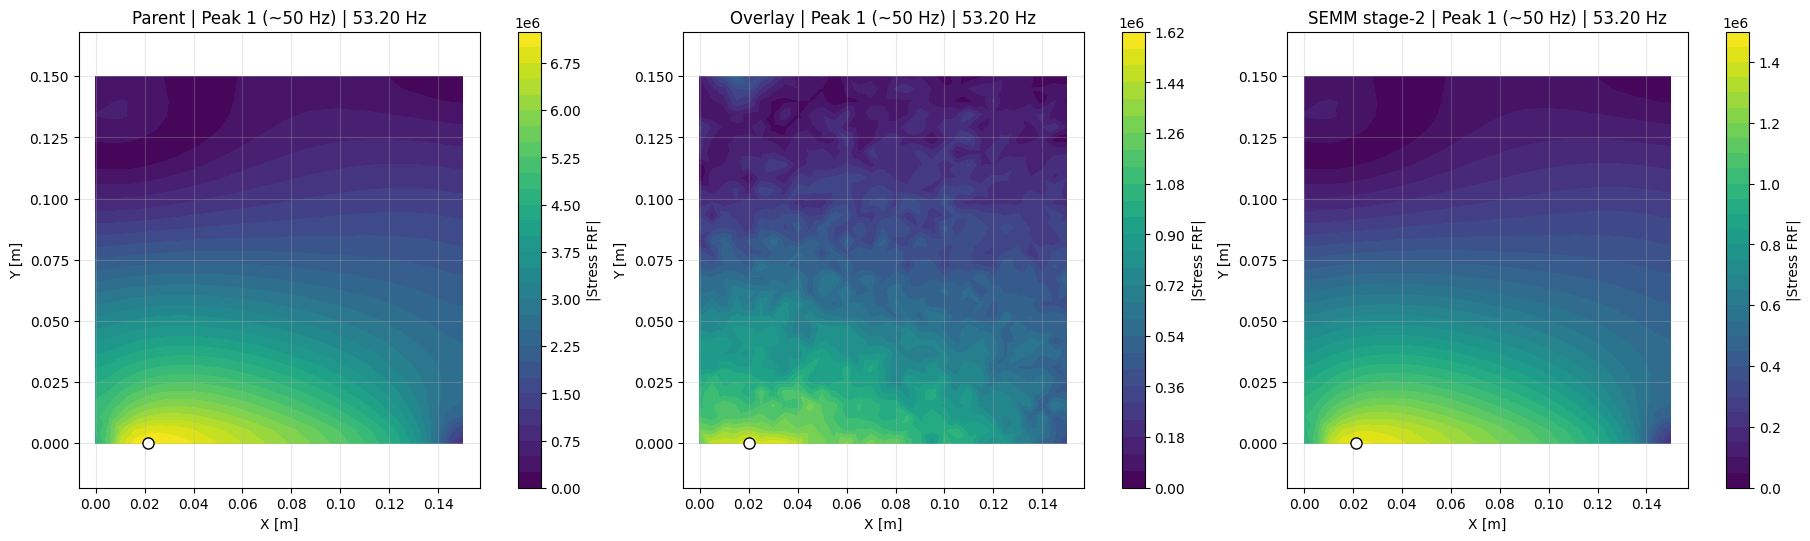

Band: {'name': 'Peak 1 (~50 Hz)', 'fmin': 40.0, 'fmax': 80.0}
Overlay-selected peak: f=53.195 Hz (k=11)
Overlay critical pixel: 903 | nearest numerical node: 5


In [20]:
# ---------------- STAGE-2 DEBUG MAP (OVERLAY PEAK, STAGE-2 STYLE) ----------------
import numpy as np
import matplotlib.pyplot as plt

stage1_data = pipe.state.get('stage1', {})
stage2_data = pipe.state.get('stage2', {})

req1 = ['freqs', 'component_overlay', 'node_coords']
req2 = ['Y_parent_acc', 'Y_overlay_base', 'Y_SEMM_stage2', 'camera_positions_stage2']
miss1 = [k for k in req1 if k not in stage1_data]
miss2 = [k for k in req2 if k not in stage2_data]
if miss1 or miss2:
    raise RuntimeError(f"Missing data for debug map plotting. stage1={miss1}, stage2={miss2}")

freq_axis = np.asarray(stage1_data['freqs'], dtype=float)
COMP2 = int(stage1_data['component_overlay'])
node_coords = np.asarray(stage1_data['node_coords'], dtype=float)
camera_positions_stage2 = np.asarray(stage2_data['camera_positions_stage2'], dtype=float)

parent2 = np.asarray(stage2_data['Y_parent_acc'][:, COMP2::4, 0])
overlay2 = np.asarray(stage2_data['Y_overlay_base'][:, :, 0])
semm2 = np.asarray(stage2_data['Y_SEMM_stage2'][:, COMP2::4, 0])

# Peak selection source: overlay
DEBUG_PEAK_BAND_INDEX = 0
if 'PEAK_BANDS' in globals() and len(PEAK_BANDS) > 0:
    bands_local = PEAK_BANDS
else:
    bands_local = [
        {'name': 'Peak 1 (~50 Hz)', 'fmin': 40.0, 'fmax': 80.0},
        {'name': 'Peak 2 (~150-200 Hz)', 'fmin': 130.0, 'fmax': 220.0},
    ]
DEBUG_PEAK_BAND_INDEX = int(np.clip(DEBUG_PEAK_BAND_INDEX, 0, len(bands_local) - 1))
band = bands_local[DEBUG_PEAK_BAND_INDEX]

metric_overlay2 = np.max(np.abs(overlay2), axis=1)
mask_band = (freq_axis >= float(band['fmin'])) & (freq_axis <= float(band['fmax']))
if not np.any(mask_band):
    raise ValueError(f"No frequencies in band [{band['fmin']}, {band['fmax']}] Hz")
idx_local = np.where(mask_band)[0]
y_local = np.nan_to_num(metric_overlay2[mask_band], nan=-np.inf, posinf=-np.inf, neginf=-np.inf)
k_peak = int(idx_local[np.argmax(y_local)])
f_peak = float(freq_axis[k_peak])

field_parent = np.abs(parent2[k_peak])
field_overlay = np.abs(overlay2[k_peak])
field_semm = np.abs(semm2[k_peak])

# White point: overlay critical pixel + nearest numerical node
io_ref = int(np.argmax(field_overlay))
d2_nodes = np.sum((node_coords[:, :2] - camera_positions_stage2[io_ref, :2]) ** 2, axis=1)
ip_ref = int(np.argmin(d2_nodes))

fig, axes = plt.subplots(1, 3, figsize=(18, 5.3), constrained_layout=True)

c0 = axes[0].tricontourf(node_coords[:, 0], node_coords[:, 1], field_parent, levels=30)
fig.colorbar(c0, ax=axes[0], label='|Stress FRF|')
axes[0].set_title(f"Parent | {band['name']} | {f_peak:.2f} Hz")
axes[0].set_xlabel('X [m]'); axes[0].set_ylabel('Y [m]'); axes[0].axis('equal'); axes[0].grid(True, alpha=0.3)
axes[0].plot(node_coords[ip_ref, 0], node_coords[ip_ref, 1], 'wo', ms=8, mec='k', mew=1.0)

c1 = axes[1].tricontourf(camera_positions_stage2[:, 0], camera_positions_stage2[:, 1], field_overlay, levels=30)
fig.colorbar(c1, ax=axes[1], label='|Stress FRF|')
axes[1].set_title(f"Overlay | {band['name']} | {f_peak:.2f} Hz")
axes[1].set_xlabel('X [m]'); axes[1].set_ylabel('Y [m]'); axes[1].axis('equal'); axes[1].grid(True, alpha=0.3)
axes[1].plot(camera_positions_stage2[io_ref, 0], camera_positions_stage2[io_ref, 1], 'wo', ms=8, mec='k', mew=1.0)

c2 = axes[2].tricontourf(node_coords[:, 0], node_coords[:, 1], field_semm, levels=30)
fig.colorbar(c2, ax=axes[2], label='|Stress FRF|')
axes[2].set_title(f"SEMM stage-2 | {band['name']} | {f_peak:.2f} Hz")
axes[2].set_xlabel('X [m]'); axes[2].set_ylabel('Y [m]'); axes[2].axis('equal'); axes[2].grid(True, alpha=0.3)
axes[2].plot(node_coords[ip_ref, 0], node_coords[ip_ref, 1], 'wo', ms=8, mec='k', mew=1.0)

plt.show()

print('Band:', band)
print(f'Overlay-selected peak: f={f_peak:.3f} Hz (k={k_peak})')
print(f'Overlay critical pixel: {io_ref} | nearest numerical node: {ip_ref}')


In [ ]:
# ---------------- STAGE-2 INTERACTIVE MAP + FRF ----------------
import numpy as np
import matplotlib.tri as mtri

# Try to force an external interactive backend (Qt) for real-time callbacks.
try:
    _ipy = get_ipython()
    if _ipy is not None:
        _ipy.run_line_magic('matplotlib', 'qt')
except Exception as _be:
    print(f"Could not switch to Qt backend automatically: {_be}")

import matplotlib
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
print('Matplotlib backend for this cell:', matplotlib.get_backend())

stage1_data = pipe.state.get('stage1', {})
stage2_data = pipe.state.get('stage2', {})

req1 = ['freqs', 'component_overlay', 'node_coords']
req2 = ['Y_parent_acc', 'Y_overlay_base', 'Y_SEMM_stage2', 'camera_positions_stage2']
miss1 = [k for k in req1 if k not in stage1_data]
miss2 = [k for k in req2 if k not in stage2_data]
if miss1 or miss2:
    raise RuntimeError(f"Missing data for stage-2 interactive plot. stage1={miss1}, stage2={miss2}")

freq_axis = np.asarray(stage1_data['freqs'], dtype=float)
node_coords = np.asarray(stage1_data['node_coords'], dtype=float)
COMP2 = int(stage1_data['component_overlay'])

parent2 = np.asarray(stage2_data['Y_parent_acc'][:, COMP2::4, 0])
overlay2 = np.asarray(stage2_data['Y_overlay_base'][:, :, 0])
semm2 = np.asarray(stage2_data['Y_SEMM_stage2'][:, COMP2::4, 0])
camera_positions_stage2 = np.asarray(stage2_data['camera_positions_stage2'], dtype=float)

# Full arrays for all-component maps (4 interleaved components)
Y_parent_acc_full = np.asarray(stage2_data['Y_parent_acc'][:, :, 0])
Y_SEMM_stage2_full = np.asarray(stage2_data['Y_SEMM_stage2'][:, :, 0])

if parent2.shape[0] != len(freq_axis) or overlay2.shape[0] != len(freq_axis) or semm2.shape[0] != len(freq_axis):
    raise ValueError('Frequency dimension mismatch between stage-2 arrays and stage-1 frequency axis.')

# overlay grid size
if 'diag_cam_stage2' in stage2_data and isinstance(stage2_data['diag_cam_stage2'], dict):
    rows2 = int(stage2_data['diag_cam_stage2'].get('rows', 0))
    cols2 = int(stage2_data['diag_cam_stage2'].get('cols', 0))
else:
    rows2 = 0
    cols2 = 0
if rows2 <= 0 or cols2 <= 0 or rows2 * cols2 != overlay2.shape[1]:
    rows2 = int(round(np.sqrt(overlay2.shape[1])))
    cols2 = int(overlay2.shape[1] // max(rows2, 1))
if rows2 * cols2 != overlay2.shape[1]:
    raise ValueError(
        f"Cannot infer overlay grid shape for stage-2 map: npix={overlay2.shape[1]}, rows={rows2}, cols={cols2}"
    )

# camera-pixel -> numerical-node mapping
cam_to_num = stage2_data.get('cam_to_num_idx_stage2', None)
if cam_to_num is None:
    d2 = np.sum((camera_positions_stage2[:, None, :2] - node_coords[None, :, :2]) ** 2, axis=2)
    cam_to_num = np.argmin(d2, axis=1)
cam_to_num = np.asarray(cam_to_num, dtype=int)
if len(cam_to_num) != overlay2.shape[1]:
    d2 = np.sum((camera_positions_stage2[:, None, :2] - node_coords[None, :, :2]) ** 2, axis=2)
    cam_to_num = np.argmin(d2, axis=1)

# ---------------- SETTINGS ----------------
F_VIEW_MIN = max(float(freq_axis.min()), 40.0)
F_VIEW_MAX = min(float(freq_axis.max()), 300.0)
DEFAULT_MAP_HZ = 55.0

SNAP_TO_PEAKS = False
SNAP_SOURCE = 'overlay'   # 'all' | 'parent' | 'overlay' | 'semm'
PEAK_HEIGHT_REL = 0.02
PEAK_PROM_REL = 0.02
PEAK_HEIGHT_REL_OVERLAY = 0.005   # lower threshold for overlay
PEAK_PROM_REL_OVERLAY = 0.005
PEAK_MIN_DISTANCE_HZ = 1.0
PEAK_EDGE_EXCLUDE_HZ = 2.0
SNAP_MAX_DELTA_HZ = 12.0
SHOW_PEAK_MARKERS = True
SHOW_ACTIVE_PEAK_TEXT = True
SHOW_ACTIVE_PEAK_VLINES = True

# Component-map settings
PLOT_ALL_COMPONENT_PEAK_MAPS = True
MAP_COMPONENT_SEQUENCE = [
    (3, 'SX+SY', True),   # (comp_index, label, has_overlay)
    (0, 'SX',    False),
    (1, 'SY',    False),
    (2, 'SXY',   False),
]
PEAK_MAP_USE_NEAREST_PEAK_TO_CURSOR = False
UPDATE_COMPONENT_MAPS_DURING_DRAG = False

band_idx = np.where((freq_axis >= F_VIEW_MIN) & (freq_axis <= F_VIEW_MAX))[0]
if len(band_idx) == 0:
    raise ValueError(f"No frequencies in view band [{F_VIEW_MIN}, {F_VIEW_MAX}] Hz")

f_map_idx = int(np.argmin(np.abs(freq_axis - float(DEFAULT_MAP_HZ))))
f_map_idx = int(np.clip(f_map_idx, band_idx[0], band_idx[-1]))

eps = np.finfo(float).tiny

# ---- helpers ----

def _safe_clim(values):
    """Get safe color limits, handling NaN and inf."""
    arr = np.asarray(values, dtype=float)
    finite = np.isfinite(arr)
    if not np.any(finite):
        return 0.0, 1.0
    lo, hi = np.percentile(arr[finite], [1, 99])
    if not np.isfinite(lo) or not np.isfinite(hi) or hi <= lo:
        lo, hi = float(np.nanmin(arr)), float(np.nanmax(arr))
    if not np.isfinite(lo) or not np.isfinite(hi) or hi <= lo:
        lo, hi = 0.0, 1.0
    return lo, hi


def _detect_peaks_on_curve(y_full, height_rel=None, prom_rel=None):
    y = np.asarray(y_full, dtype=float)
    yb = np.nan_to_num(y[band_idx], nan=-np.inf, posinf=-np.inf, neginf=-np.inf)
    idxb = band_idx

    if len(idxb) <= 1:
        return np.asarray([], dtype=int)

    df = float(np.median(np.diff(freq_axis[idxb])))
    if (not np.isfinite(df)) or (df <= 0):
        df = 1.0
    min_dist_bins = max(1, int(round(float(PEAK_MIN_DISTANCE_HZ) / max(df, 1e-12))))

    kwargs = {'distance': min_dist_bins}
    _hr = height_rel if height_rel is not None else PEAK_HEIGHT_REL
    _pr = prom_rel if prom_rel is not None else PEAK_PROM_REL
    y_max = float(np.max(yb[np.isfinite(yb)])) if np.any(np.isfinite(yb)) else 0.0
    if np.isfinite(y_max) and y_max > 0:
        if _hr is not None and _hr > 0:
            kwargs['height'] = float(_hr) * y_max
        if _pr is not None and _pr > 0:
            kwargs['prominence'] = float(_pr) * y_max

    peaks_rel, _ = find_peaks(yb, **kwargs)

    edge_bins = max(0, int(round(float(PEAK_EDGE_EXCLUDE_HZ) / max(df, 1e-12))))
    if peaks_rel.size > 0 and edge_bins > 0 and (2 * edge_bins + 1) < len(yb):
        peaks_rel = peaks_rel[(peaks_rel >= edge_bins) & (peaks_rel <= (len(yb) - 1 - edge_bins))]

    if peaks_rel.size == 0:
        return np.asarray([], dtype=int)

    return np.asarray(idxb[peaks_rel], dtype=int)


def _set_peak_scatter(sc_obj, idx, y_full):
    if not SHOW_PEAK_MARKERS or idx is None or len(idx) == 0:
        sc_obj.set_offsets(np.empty((0, 2)))
        return
    xx = freq_axis[idx]
    yy = np.asarray(y_full, dtype=float)[idx]
    sc_obj.set_offsets(np.column_stack([xx, yy]))


def _nearest_peak_idx(peaks_idx, ref_idx):
    if peaks_idx is None or len(peaks_idx) == 0:
        return int(ref_idx)
    j = int(np.argmin(np.abs(np.asarray(peaks_idx, dtype=int) - int(ref_idx))))
    return int(peaks_idx[j])


def _set_single_marker(sc, idx, y_curve, visible=True):
    if (idx is None) or (not visible):
        sc.set_offsets(np.empty((0, 2)))
        return
    y = np.asarray(y_curve, dtype=float)
    if idx < 0 or idx >= y.size:
        sc.set_offsets(np.empty((0, 2)))
        return
    sc.set_offsets(np.array([[freq_axis[idx], y[idx]]], dtype=float))


def _set_vline(vl, idx, visible=True):
    if (idx is None) or (not visible):
        vl.set_visible(False)
        return
    vl.set_visible(True)
    vl.set_xdata([freq_axis[idx], freq_axis[idx]])


# ---- main figure ----

fig, (ax_map, ax_frf) = plt.subplots(1, 2, figsize=(15.0, 5.3))

map_img = np.abs(overlay2[f_map_idx]).reshape(rows2, cols2)
finite = np.isfinite(map_img)
if np.any(finite):
    vmin, vmax = np.percentile(map_img[finite], [1, 99])
else:
    vmin, vmax = None, None

im = ax_map.imshow(map_img, origin='upper', vmin=vmin, vmax=vmax, cmap='viridis')
plt.colorbar(im, ax=ax_map, fraction=0.046, pad=0.04)
ax_map.set_title(f"Stage-2 overlay map @ {freq_axis[f_map_idx]:.3f} Hz")
ax_map.set_xlabel('col')
ax_map.set_ylabel('row')
marker, = ax_map.plot([], [], 'wo', ms=8, mew=1.2, mec='k')

line_p, = ax_frf.semilogy([], [], label='Parent (node)')
line_o, = ax_frf.semilogy([], [], label='Overlay (pixel)')
line_s, = ax_frf.semilogy([], [], label='SEMM (node)')
vline = ax_frf.axvline(freq_axis[f_map_idx], color='k', ls='--', lw=1.5, alpha=0.85, label='Map frequency')

peak_p = ax_frf.scatter([], [], s=38, marker='o', facecolors='none', edgecolors='C0', linewidths=1.2, label='Parent peaks')
peak_o = ax_frf.scatter([], [], s=38, marker='s', facecolors='none', edgecolors='C1', linewidths=1.2, label='Overlay peaks')
peak_s = ax_frf.scatter([], [], s=38, marker='^', facecolors='none', edgecolors='C2', linewidths=1.2, label='SEMM peaks')

active_p = ax_frf.scatter([], [], s=90, marker='o', facecolors='C0', edgecolors='k', linewidths=0.8, zorder=9)
active_o = ax_frf.scatter([], [], s=90, marker='s', facecolors='C1', edgecolors='k', linewidths=0.8, zorder=9)
active_s = ax_frf.scatter([], [], s=90, marker='^', facecolors='C2', edgecolors='k', linewidths=0.8, zorder=9)

# Active peak vertical lines (colored, per model)
active_vline_p = ax_frf.axvline(freq_axis[f_map_idx], color='C0', ls=':', lw=1.0, alpha=0.55)
active_vline_o = ax_frf.axvline(freq_axis[f_map_idx], color='C1', ls=':', lw=1.0, alpha=0.55)
active_vline_s = ax_frf.axvline(freq_axis[f_map_idx], color='C2', ls=':', lw=1.0, alpha=0.55)

peak_info_text = ax_frf.text(
    0.01,
    0.98,
    '',
    transform=ax_frf.transAxes,
    va='top',
    ha='left',
    fontsize=8,
    family='monospace',
    bbox=dict(boxstyle='round,pad=0.25', fc='white', ec='0.7', alpha=0.85),
)

ax_frf.set_xlabel('Frequency [Hz]')
ax_frf.set_ylabel('|Stress FRF| [Pa/(m/s^2)]')
ax_frf.grid(True, which='both', ls='--', alpha=0.4)
ax_frf.legend(fontsize=8, ncol=2)
ax_frf.set_xlim(F_VIEW_MIN, F_VIEW_MAX)

state = {
    'pix': 0,
    'r': 0,
    'c': 0,
    'i_num': 0,
    'map_idx': int(f_map_idx),
    'curves': {},
    'peaks': {},
    'dragging_freq': False,
    'last_snap_label': None,
    'component_maps': None,
}


def _update_active_peak_visuals():
    ref_idx = int(state['map_idx'])
    p = state['curves'].get('parent', None)
    o = state['curves'].get('overlay', None)
    s = state['curves'].get('semm', None)
    if p is None or o is None or s is None:
        return

    k_p = _nearest_peak_idx(state['peaks'].get('parent', np.array([], dtype=int)), ref_idx)
    k_o = _nearest_peak_idx(state['peaks'].get('overlay', np.array([], dtype=int)), ref_idx)
    k_s = _nearest_peak_idx(state['peaks'].get('semm', np.array([], dtype=int)), ref_idx)

    _set_single_marker(active_p, k_p, p, True)
    _set_single_marker(active_o, k_o, o, True)
    _set_single_marker(active_s, k_s, s, True)

    _set_vline(active_vline_p, k_p, SHOW_ACTIVE_PEAK_VLINES)
    _set_vline(active_vline_o, k_o, SHOW_ACTIVE_PEAK_VLINES)
    _set_vline(active_vline_s, k_s, SHOW_ACTIVE_PEAK_VLINES)

    if SHOW_ACTIVE_PEAK_TEXT:
        f_ref = freq_axis[ref_idx]
        f_p = freq_axis[k_p]
        f_o = freq_axis[k_o]
        f_s = freq_axis[k_s]
        snap_txt = f" ({state['last_snap_label']})" if state['last_snap_label'] else ""
        peak_info_text.set_text(
            f"cursor : {f_ref:8.3f} Hz{snap_txt}\n"
            f"parent : {f_p:8.3f} Hz  (d={f_p-f_ref:+7.3f})\n"
            f"overlay: {f_o:8.3f} Hz  (d={f_o-f_ref:+7.3f})\n"
            f"semm   : {f_s:8.3f} Hz  (d={f_s-f_ref:+7.3f})"
        )


def _update_titles():
    pix = state['pix']
    r = state['r']
    c = state['c']
    i_num = state['i_num']
    f_cur = freq_axis[state['map_idx']]
    ax_map.set_title(f"Stage-2 overlay map @ {f_cur:.3f} Hz | pix={pix} (r={r}, c={c})")
    ax_frf.set_title(f"Stage-2 FRFs at pix={pix} -> node={i_num}")


# ---- component maps (separate window) ----

def _build_component_map_figure():
    if not PLOT_ALL_COMPONENT_PEAK_MAPS:
        return None

    # Per-component peak detection on spatial RMS metric
    overlay_metric = np.sqrt(np.mean(np.abs(overlay2) ** 2, axis=1))
    overlay_peaks = _detect_peaks_on_curve(overlay_metric, height_rel=PEAK_HEIGHT_REL_OVERLAY, prom_rel=PEAK_PROM_REL_OVERLAY)

    comp_meta = {}
    for comp, comp_name, has_overlay in MAP_COMPONENT_SEQUENCE:
        parent_comp = np.abs(Y_parent_acc_full[:, comp::4])
        semm_comp = np.abs(Y_SEMM_stage2_full[:, comp::4])

        parent_metric = np.sqrt(np.mean(parent_comp ** 2, axis=1))
        semm_metric = np.sqrt(np.mean(semm_comp ** 2, axis=1))

        comp_meta[comp] = {
            'name': comp_name,
            'has_overlay': bool(has_overlay),
            'parent_peaks': _detect_peaks_on_curve(parent_metric),
            'semm_peaks': _detect_peaks_on_curve(semm_metric),
        }

    nrows = len(MAP_COMPONENT_SEQUENCE)
    fig2, axes2 = plt.subplots(nrows, 3, figsize=(18, 4.6 * nrows), constrained_layout=True)
    if nrows == 1:
        axes2 = np.asarray([axes2])

    tri_num = mtri.Triangulation(node_coords[:, 0], node_coords[:, 1])
    tri_cam = mtri.Triangulation(camera_positions_stage2[:, 0], camera_positions_stage2[:, 1])

    k0 = int(np.clip(state['map_idx'], 0, len(freq_axis) - 1))
    artists = []

    for rr, (comp, comp_name, has_overlay) in enumerate(MAP_COMPONENT_SEQUENCE):
        comp = int(comp)

        field_parent0 = np.abs(Y_parent_acc_full[k0, comp::4])
        field_semm0 = np.abs(Y_SEMM_stage2_full[k0, comp::4])

        # Parent (column 0)
        ax_parent = axes2[rr, 0]
        lo, hi = _safe_clim(field_parent0)
        pc_parent = ax_parent.tripcolor(tri_num, field_parent0, shading='gouraud',
                                        cmap='viridis', vmin=lo, vmax=hi)
        fig2.colorbar(pc_parent, ax=ax_parent, label='|Stress FRF|')
        ax_parent.set_title(f"Parent {comp_name} @ {freq_axis[k0]:.2f} Hz")
        ax_parent.set_xlabel('X [m]')
        ax_parent.set_ylabel('Y [m]')
        ax_parent.axis('equal')

        # Overlay (column 1)
        pc_overlay = None
        ax_overlay = axes2[rr, 1]
        if has_overlay:
            field_overlay0 = np.abs(overlay2[k0])
            lo, hi = _safe_clim(field_overlay0)
            pc_overlay = ax_overlay.tripcolor(tri_cam, field_overlay0, shading='gouraud',
                                              cmap='viridis', vmin=lo, vmax=hi)
            fig2.colorbar(pc_overlay, ax=ax_overlay, label='|Stress FRF|')
            ax_overlay.set_title(f"Overlay {comp_name} @ {freq_axis[k0]:.2f} Hz")
            ax_overlay.set_xlabel('X [m]')
            ax_overlay.set_ylabel('Y [m]')
            ax_overlay.axis('equal')
        else:
            ax_overlay.axis('off')
            ax_overlay.text(0.5, 0.5, 'Overlay available only for SX+SY',
                            ha='center', va='center', transform=ax_overlay.transAxes,
                            fontsize=10, color='0.4')

        # SEMM (column 2)
        ax_semm = axes2[rr, 2]
        lo, hi = _safe_clim(field_semm0)
        pc_semm = ax_semm.tripcolor(tri_num, field_semm0, shading='gouraud',
                                    cmap='viridis', vmin=lo, vmax=hi)
        fig2.colorbar(pc_semm, ax=ax_semm, label='|Stress FRF|')
        ax_semm.set_title(f"SEMM {comp_name} @ {freq_axis[k0]:.2f} Hz")
        ax_semm.set_xlabel('X [m]')
        ax_semm.set_ylabel('Y [m]')
        ax_semm.axis('equal')

        artists.append({
            'comp': comp,
            'name': comp_name,
            'has_overlay': has_overlay,
            'ax_parent': ax_parent,
            'pc_parent': pc_parent,
            'ax_overlay': ax_overlay,
            'pc_overlay': pc_overlay,
            'ax_semm': ax_semm,
            'pc_semm': pc_semm,
        })

    return {
        'fig': fig2,
        'axes': axes2,
        'artists': artists,
        'overlay_peaks': overlay_peaks,
        'comp_meta': comp_meta,
        'tri_num': tri_num,
        'tri_cam': tri_cam,
    }


def _update_component_maps(ref_idx, announce=False):
    cm = state.get('component_maps', None)
    if cm is None:
        return

    fig2 = cm['fig']
    if fig2 is None or not plt.fignum_exists(fig2.number):
        return

    ref_idx = int(np.clip(ref_idx, 0, len(freq_axis) - 1))

    summary = []
    for art in cm['artists']:
        comp = int(art['comp'])
        name = art['name']
        meta = cm['comp_meta'][comp]

        if PEAK_MAP_USE_NEAREST_PEAK_TO_CURSOR:
            k_parent = _nearest_peak_idx(meta['parent_peaks'], ref_idx)
            k_semm = _nearest_peak_idx(meta['semm_peaks'], ref_idx)
        else:
            k_parent = ref_idx
            k_semm = ref_idx

        # Update parent field
        field_parent = np.abs(Y_parent_acc_full[k_parent, comp::4])
        art['pc_parent'].set_array(field_parent)
        lo, hi = _safe_clim(field_parent)
        art['pc_parent'].set_clim(lo, hi)
        art['ax_parent'].set_title(f"Parent {name} @ {freq_axis[k_parent]:.2f} Hz")

        # Update SEMM field
        field_semm = np.abs(Y_SEMM_stage2_full[k_semm, comp::4])
        art['pc_semm'].set_array(field_semm)
        lo, hi = _safe_clim(field_semm)
        art['pc_semm'].set_clim(lo, hi)
        art['ax_semm'].set_title(f"SEMM {name} @ {freq_axis[k_semm]:.2f} Hz")

        # Update overlay if present
        if art['has_overlay'] and art['pc_overlay'] is not None:
            if PEAK_MAP_USE_NEAREST_PEAK_TO_CURSOR:
                k_overlay = _nearest_peak_idx(cm['overlay_peaks'], ref_idx)
            else:
                k_overlay = ref_idx
            field_overlay = np.abs(overlay2[k_overlay])
            art['pc_overlay'].set_array(field_overlay)
            lo, hi = _safe_clim(field_overlay)
            art['pc_overlay'].set_clim(lo, hi)
            art['ax_overlay'].set_title(f"Overlay {name} @ {freq_axis[k_overlay]:.2f} Hz")
            summary.append(
                f"{name}: P {freq_axis[k_parent]:.2f} | O {freq_axis[k_overlay]:.2f} | S {freq_axis[k_semm]:.2f} Hz"
            )
        else:
            summary.append(
                f"{name}: P {freq_axis[k_parent]:.2f} | S {freq_axis[k_semm]:.2f} Hz"
            )

    if announce:
        print(
            f"Component maps updated from cursor at {freq_axis[ref_idx]:.3f} Hz "
            f"(nearest-peak mode: {PEAK_MAP_USE_NEAREST_PEAK_TO_CURSOR})."
        )
        for line in summary:
            print(f"  {line}")

    fig2.canvas.draw_idle()


# ---- update functions ----

def _update_from_pixel(pix, announce=True, redraw=True):
    pix = int(np.clip(pix, 0, rows2 * cols2 - 1))
    r, c = divmod(pix, cols2)

    i_num_loc = int(cam_to_num[pix])

    p = np.maximum(np.abs(parent2[:, i_num_loc]), eps)
    o = np.maximum(np.abs(overlay2[:, pix]), eps)
    s = np.maximum(np.abs(semm2[:, i_num_loc]), eps)

    line_p.set_data(freq_axis[band_idx], p[band_idx])
    line_o.set_data(freq_axis[band_idx], o[band_idx])
    line_s.set_data(freq_axis[band_idx], s[band_idx])

    peaks_p = _detect_peaks_on_curve(p)
    peaks_o = _detect_peaks_on_curve(o, height_rel=PEAK_HEIGHT_REL_OVERLAY, prom_rel=PEAK_PROM_REL_OVERLAY)
    peaks_s = _detect_peaks_on_curve(s)

    state['curves'] = {'parent': p, 'overlay': o, 'semm': s}
    state['peaks'] = {'parent': peaks_p, 'overlay': peaks_o, 'semm': peaks_s}

    _set_peak_scatter(peak_p, peaks_p, p)
    _set_peak_scatter(peak_o, peaks_o, o)
    _set_peak_scatter(peak_s, peaks_s, s)
    _update_active_peak_visuals()

    ax_frf.relim()
    ax_frf.autoscale_view(scalex=False, scaley=True)
    ax_frf.set_xlim(F_VIEW_MIN, F_VIEW_MAX)

    state['pix'] = int(pix)
    state['r'] = int(r)
    state['c'] = int(c)
    state['i_num'] = int(i_num_loc)

    marker.set_data([c], [r])
    _update_titles()

    # Also update component maps on pixel click
    _update_component_maps(state['map_idx'], announce=False)

    if announce:
        print(f"Stage-2 selection: pix={pix} (r={r}, c={c}) -> node={i_num_loc}")
        print(
            f"Peaks in [{freq_axis[band_idx[0]]:.2f}, {freq_axis[band_idx[-1]]:.2f}] Hz: "
            f"Parent={len(peaks_p)}, Overlay={len(peaks_o)}, SEMM={len(peaks_s)}"
        )

    if redraw:
        fig.canvas.draw_idle()


def _snap_idx_from_hz(f_hz):
    raw_idx = int(np.argmin(np.abs(freq_axis - float(f_hz))))
    raw_idx = int(np.clip(raw_idx, band_idx[0], band_idx[-1]))

    if not SNAP_TO_PEAKS:
        return raw_idx, None

    peaks = state.get('peaks', {})
    cand = []
    src = str(SNAP_SOURCE).lower()
    if src in ('all', 'parent'):
        cand += [(int(k), 'parent') for k in np.asarray(peaks.get('parent', []), dtype=int)]
    if src in ('all', 'overlay'):
        cand += [(int(k), 'overlay') for k in np.asarray(peaks.get('overlay', []), dtype=int)]
    if src in ('all', 'semm'):
        cand += [(int(k), 'semm') for k in np.asarray(peaks.get('semm', []), dtype=int)]

    if len(cand) == 0:
        return raw_idx, None

    arr_idx = np.array([k for k, _ in cand], dtype=int)
    dist_hz = np.abs(freq_axis[arr_idx] - float(f_hz))
    j = int(np.argmin(dist_hz))

    if SNAP_MAX_DELTA_HZ is not None and np.isfinite(float(SNAP_MAX_DELTA_HZ)):
        if float(dist_hz[j]) > float(SNAP_MAX_DELTA_HZ):
            return raw_idx, None

    return int(arr_idx[j]), str(cand[j][1])


def _update_map_frequency_from_idx(map_idx, announce=False, redraw=True,
                                    snap_label=None, update_component_maps=True):
    map_idx = int(np.clip(map_idx, band_idx[0], band_idx[-1]))
    state['map_idx'] = int(map_idx)
    state['last_snap_label'] = snap_label

    map_new = np.abs(overlay2[map_idx]).reshape(rows2, cols2)
    im.set_data(map_new)

    finite = np.isfinite(map_new)
    if np.any(finite):
        lo, hi = np.percentile(map_new[finite], [1, 99])
        if np.isfinite(lo) and np.isfinite(hi) and hi > lo:
            im.set_clim(lo, hi)

    vline.set_xdata([freq_axis[map_idx], freq_axis[map_idx]])
    _update_active_peak_visuals()
    _update_titles()

    if update_component_maps:
        _update_component_maps(map_idx, announce=announce)

    if announce and not update_component_maps:
        extra = f" | snapped to {snap_label}" if snap_label else ""
        print(f"Map frequency set to {freq_axis[map_idx]:.3f} Hz (idx={map_idx}){extra}")

    if redraw:
        fig.canvas.draw_idle()


def _update_map_frequency_from_hz(f_hz, announce=False, redraw=True,
                                   update_component_maps=True):
    snap_idx, snap_src = _snap_idx_from_hz(float(f_hz))
    _update_map_frequency_from_idx(
        snap_idx,
        announce=announce,
        redraw=redraw,
        snap_label=snap_src,
        update_component_maps=update_component_maps,
    )


# ---- event handlers ----

def _on_press(event):
    if event.inaxes == ax_map:
        if event.xdata is None or event.ydata is None:
            return
        c = int(np.rint(event.xdata))
        r = int(np.rint(event.ydata))
        if not (0 <= r < rows2 and 0 <= c < cols2):
            return
        pix = r * cols2 + c
        _update_from_pixel(pix, announce=True, redraw=True)
        return

    if event.inaxes == ax_frf:
        if event.xdata is None:
            return
        state['dragging_freq'] = True
        _update_map_frequency_from_hz(event.xdata, announce=True, redraw=True,
                                       update_component_maps=True)


def _on_motion(event):
    if not state['dragging_freq']:
        return
    if event.inaxes != ax_frf or event.xdata is None:
        return
    _update_map_frequency_from_hz(event.xdata, announce=False, redraw=True,
                                   update_component_maps=bool(UPDATE_COMPONENT_MAPS_DURING_DRAG))


def _on_release(event):
    if not state['dragging_freq']:
        return
    state['dragging_freq'] = False
    if event.inaxes == ax_frf and event.xdata is not None:
        _update_map_frequency_from_hz(event.xdata, announce=True, redraw=True,
                                       update_component_maps=True)


# ---- initialization ----

# Initialize at overlay maximum around DEFAULT_MAP_HZ (band-limited)
idx0 = int(np.argmin(np.abs(freq_axis[band_idx] - float(DEFAULT_MAP_HZ))))
idx0 = int(band_idx[idx0])
pix0 = int(np.argmax(np.abs(overlay2[idx0])))

_update_from_pixel(pix0, announce=True, redraw=False)

# Build the separate component-maps window
state['component_maps'] = _build_component_map_figure()

_update_map_frequency_from_idx(idx0, announce=False, redraw=False,
                                update_component_maps=True)

cid_press = fig.canvas.mpl_connect('button_press_event', _on_press)
cid_motion = fig.canvas.mpl_connect('motion_notify_event', _on_motion)
cid_release = fig.canvas.mpl_connect('button_release_event', _on_release)

plt.figure(fig.number)
plt.tight_layout()

# Try to raise the external window (Qt/Tk backends).
try:
    mgr = plt.get_current_fig_manager()
    if hasattr(mgr, 'window'):
        try:
            mgr.window.show()
            if hasattr(mgr.window, 'activateWindow'):
                mgr.window.activateWindow()
            if hasattr(mgr.window, 'raise_'):
                mgr.window.raise_()
        except Exception:
            pass
except Exception:
    pass

plt.show(block=False)

print(f"\nInteractive callbacks connected: press={cid_press}, motion={cid_motion}, release={cid_release}.")
print("Click on the left overlay map to update FRF location.")
print("Click/drag on FRF plot: map frequency cursor snaps to nearest detected peak.")
print(f"Component maps window: {'ACTIVE' if state['component_maps'] else 'DISABLED'} "
      f"(update during drag: {UPDATE_COMPONENT_MAPS_DURING_DRAG})")
print(
    f"Peak tuning: height_rel={PEAK_HEIGHT_REL}, prom_rel={PEAK_PROM_REL}, "
    f"min_distance_hz={PEAK_MIN_DISTANCE_HZ}, snap_source='{SNAP_SOURCE}'"
)

Matplotlib backend for this cell: qtagg
Stage-2 selection: pix=904 (r=29, c=5) -> node=6
Peaks in [45.60, 299.83] Hz: Parent=10, Overlay=23, SEMM=21

Interactive callbacks connected: press=14, motion=15, release=16.
Click on the left overlay map to update FRF location.
Click/drag on FRF plot: map frequency cursor snaps to nearest detected peak.
Component maps window: ACTIVE (update during drag: False)
Peak tuning: height_rel=0.02, prom_rel=0.02, min_distance_hz=1.0, snap_source='overlay'


Stage-2 selection: pix=925 (r=29, c=26) -> node=25
Peaks in [45.60, 299.83] Hz: Parent=38, Overlay=27, SEMM=22
Component maps updated from cursor at 176.166 Hz (nearest-peak mode: False).
  SX+SY: P 176.17 | O 176.17 | S 176.17 Hz
  SX: P 176.17 | S 176.17 Hz
  SY: P 176.17 | S 176.17 Hz
  SXY: P 176.17 | S 176.17 Hz
Component maps updated from cursor at 176.166 Hz (nearest-peak mode: False).
  SX+SY: P 176.17 | O 176.17 | S 176.17 Hz
  SX: P 176.17 | S 176.17 Hz
  SY: P 176.17 | S 176.17 Hz
  SXY: P 176.17 | S 176.17 Hz
Component maps updated from cursor at 174.784 Hz (nearest-peak mode: False).
  SX+SY: P 174.78 | O 174.78 | S 174.78 Hz
  SX: P 174.78 | S 174.78 Hz
  SY: P 174.78 | S 174.78 Hz
  SXY: P 174.78 | S 174.78 Hz
Component maps updated from cursor at 174.784 Hz (nearest-peak mode: False).
  SX+SY: P 174.78 | O 174.78 | S 174.78 Hz
  SX: P 174.78 | S 174.78 Hz
  SY: P 174.78 | S 174.78 Hz
  SXY: P 174.78 | S 174.78 Hz
Component maps updated from cursor at 172.712 Hz (nearest